In [1]:
import glob, os
import numpy as np
import pandas as pd
import matplotlib as mpl
from pathlib import Path
import astropy.units as u
from astropy.table import Table
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from astropy.coordinates import SkyCoord
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec

from myutils import all_utils as au



In [2]:
# Path plots
path_plots = "paper_plots/ocean/"
os.mkdir(path_plots) if not os.path.exists(path_plots) else None


In [3]:

df_header_list=[]
df_phot_list=[]
list_to_read = glob.glob("data/SIMS_KN_OCEAN/*/*PHOT.FITS.gz")
print(f"Found {len(list_to_read)} PHOT.FITS.gz files to read.")
for fphot in list_to_read:
    df_header_tmp, df_phot_tmp = au.read_fits(fphot, drop_separators=True)
    print(f"Reading {fphot} with length {len(df_phot_tmp)}")
    df_header_list.append(df_header_tmp)
    df_phot_list.append(df_phot_tmp)
df_header = pd.concat(df_header_list, ignore_index=True)
# Read all PHOT.FITS.gz files and concatenate them    
df_phot = pd.concat(df_phot_list, ignore_index=True)
print(f"Number of light curves: {len(df_header)}")
print(f"Number of photometric points: {df_phot.groupby('SNID').count()['MJD'].median()} +- {df_phot.groupby('SNID').count()['MJD'].std()}")

Found 2 PHOT.FITS.gz files to read.


/Users/amoller/Science/KN_OzGrav/KNcand_LVK/Rubin_KNe_with_Fink_LVK/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/amoller/Science/KN_OzGrav/KNcand_LVK/Rubin_KNe_with_Fink_LVK/myutils/all_utils.py:163: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'ELAISS1' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_header.loc[within, "ddf_field_name"] = field


Reading data/SIMS_KN_OCEAN/PIP_AMR_KN_OCEAN_LSST_KN_KASEN_NOHOST/PIP_AMR_KN_OCEAN_LSST_KN_5c695_NONIaMODEL00-0001_PHOT.FITS.gz with length 254854


/Users/amoller/Science/KN_OzGrav/KNcand_LVK/Rubin_KNe_with_Fink_LVK/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/amoller/Science/KN_OzGrav/KNcand_LVK/Rubin_KNe_with_Fink_LVK/myutils/all_utils.py:163: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'ELAISS1' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_header.loc[within, "ddf_field_name"] = field


Reading data/SIMS_KN_OCEAN/PIP_AMR_KN_OCEAN_LSST_KN_BULLA_NOHOST/PIP_AMR_KN_OCEAN_LSST_KN_2bc10_NONIaMODEL00-0001_PHOT.FITS.gz with length 254854
Number of light curves: 22976
Number of photometric points: 18.0 +- 55.476461113981976


In [4]:
df_header.groupby('model_name').count()['SNID']

model_name
Bulla    11488
Kasen    11488
Name: SNID, dtype: int64

In [5]:
dic_gt5 = {}
for typ in df_header.SIM_GENTYPE.unique():
    
    # Select matching SNIDs from df_phot
    sel_snids = df_header[df_header.SIM_GENTYPE == typ].SNID
    print(f"\nNumber of light curves with SIM_GENTYPE = {typ} | {au.dic_sntype[str(typ)]}: {len(sel_snids)}")

    # Total SNIDs for this SIM_GENTYPE
    total_typ_snids = len(sel_snids)

    # Photometry
    sel = df_phot[df_phot.SNID.isin(sel_snids)]
    print(f"Number of photometric points for this type: {len(sel)}")

    # Compute SNR thresholds
    typ_str = au.dic_sntype[f"{typ}"]
    dic_gt5[typ_str] = sel[sel['SNR'] > 5]
    snr_gt_5 = dic_gt5[typ_str]['SNID'].nunique()
    snr_gt_3 = sel[sel['SNR'] > 3]['SNID'].nunique()

    # Group by SNID, count how many SNR > 5 measurements each has
    snr_gt5_counts = dic_gt5[typ_str].groupby('SNID').size()

    # Count how many SNIDs have at least two such measurements
    snr_gt5_atleast2 = (snr_gt5_counts >= 2).sum()

    # Group by SNID and check MJD separation
    def has_two_sep_days(group):
        mjds = group['MJD'].sort_values().values
        for i in range(len(mjds)):
            for j in range(i+1, len(mjds)):
                if abs(mjds[j] - mjds[i]) > 1:
                    return True
        return False

    # Apply the function to each group
    snids_with_two_sep_days = dic_gt5[typ_str].groupby('SNID').filter(has_two_sep_days)['SNID'].nunique()
    

    print(f"{snr_gt_5} light curves have 1 detection with SNR > 5 = {snr_gt_5 / total_typ_snids * 100:.2f}% of this type")
    print(f"{snr_gt5_atleast2} light curves have 2 detections with SNR > 5 = {snr_gt5_atleast2 / total_typ_snids * 100:.2f}% of this type")
    print(f"{snids_with_two_sep_days} light curves have 2 detections with SNR > 5 in >1 day = {snids_with_two_sep_days / total_typ_snids * 100:.2f}% of this type")

    print("")
    print(f"{snr_gt_3} light curves have 1 detection with SNR > 3 = {snr_gt_3 / total_typ_snids * 100:.2f}% of this type")



Number of light curves with SIM_GENTYPE = 50 | Kasen: 11488
Number of photometric points for this type: 254854
848 light curves have 1 detection with SNR > 5 = 7.38% of this type
488 light curves have 2 detections with SNR > 5 = 4.25% of this type
202 light curves have 2 detections with SNR > 5 in >1 day = 1.76% of this type

1794 light curves have 1 detection with SNR > 3 = 15.62% of this type

Number of light curves with SIM_GENTYPE = 51 | Bulla: 11488
Number of photometric points for this type: 254854
1308 light curves have 1 detection with SNR > 5 = 11.39% of this type
744 light curves have 2 detections with SNR > 5 = 6.48% of this type
178 light curves have 2 detections with SNR > 5 in >1 day = 1.55% of this type

2327 light curves have 1 detection with SNR > 3 = 20.26% of this type


In [6]:
for typ in dic_gt5.keys():
    # Count number of rows with SNR > 5 per BAND
    snr_gt5_by_band = dic_gt5[typ_str].groupby('BAND').size()

    # Find the BAND with the most such entries
    most_common_band = snr_gt5_by_band.idxmax()
    count_most_common_band = snr_gt5_by_band.max()
    print(f"{typ}: The most common BAND with SNR > 5 is {most_common_band} with {count_most_common_band} entries.")
    print(snr_gt5_by_band)
# Combine SNIDs from both models
snids_all_snr_gt5 = np.concatenate([
    dic_gt5['Bulla'].SNID.values, 
    dic_gt5['Kasen'].SNID.values
])

Kasen: The most common BAND with SNR > 5 is LSST-i with 922 entries.
BAND
LSST-Y    227
LSST-g    191
LSST-i    922
LSST-r    777
LSST-u     30
LSST-z    586
dtype: int64
Bulla: The most common BAND with SNR > 5 is LSST-i with 922 entries.
BAND
LSST-Y    227
LSST-g    191
LSST-i    922
LSST-r    777
LSST-u     30
LSST-z    586
dtype: int64


/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_86831/295937757.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  snids_count_sep_days = dic_gt5[typ].groupby('SNID').apply(lambda x: delta_days(x))
/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_86831/295937757.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  snids_count_sep_days = dic_gt5[typ].groupby('SNID').apply(lambda x: delta_days(x))


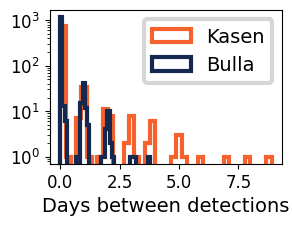

In [9]:
def delta_days(group):
    mjds = group['MJD'].sort_values().values
    for i in range(len(mjds)):
        for j in range(i+1, len(mjds)):
            return mjds[j] - mjds[i]
    return 0
fig = plt.figure(figsize=(3, 2))
for typ in dic_gt5.keys():
    snids_count_sep_days = dic_gt5[typ].groupby('SNID').apply(lambda x: delta_days(x))
    plt.hist(snids_count_sep_days, bins=40, histtype='step',label=typ,color=au.dic_KN_models_colors[typ])
plt.yscale('log')
plt.xlabel('Days between detections')
plt.legend()

Text(0.5, 0, 'Simulated redshift')

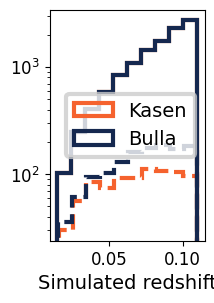

In [10]:
fig = plt.figure(figsize=(2,3))
color_list = ['blue','orange']
for m, model in enumerate(df_header.model_name.unique()):
    sel = df_header[df_header.model_name == model]
    plt.hist(sel['SIM_REDSHIFT_CMB'], label=model, histtype='step', color= au.dic_KN_models_colors[model])
    # SNR>5
    sel = sel[sel.SNID.isin(snids_all_snr_gt5)]
    plt.hist(sel['SIM_REDSHIFT_CMB'], histtype='step', color= au.dic_KN_models_colors[model], linestyle='dashed')
plt.legend()
plt.yscale('log')
plt.xlabel('Simulated redshift')

/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_86831/1287723942.py:28: RuntimeWarning: invalid value encountered in divide
  efficiency = counts_snr / counts_sim
/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_86831/1287723942.py:30: RuntimeWarning: invalid value encountered in divide
  err_efficiency = np.sqrt((err_data / counts_snr) ** 2 +
/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_86831/1287723942.py:31: RuntimeWarning: invalid value encountered in divide
  (err_sim / counts_sim) ** 2) * efficiency


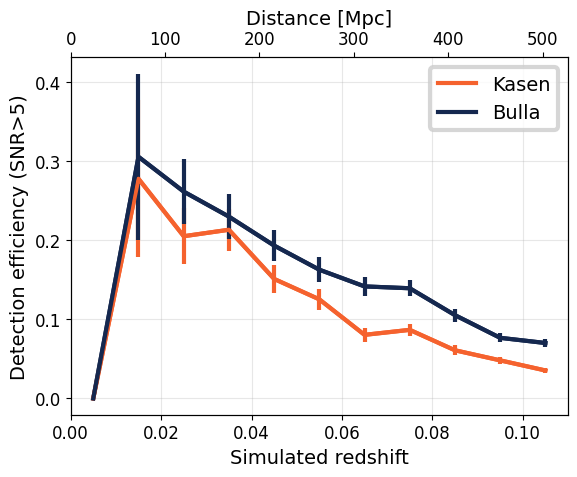

In [12]:
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo
import numpy as np

fig = plt.figure(figsize=(6,5))
ax = plt.gca()
color_list = ['blue', 'orange']

# Define redshift bins
bins = np.linspace(0, max(df_header['SIM_REDSHIFT_CMB']), 12)
bin_centers = 0.5 * (bins[1:] + bins[:-1])

for m, model in enumerate(df_header.model_name.unique()):
    sel = df_header[df_header.model_name == model]
    
    # All events
    counts_sim, _ = np.histogram(sel['SIM_REDSHIFT_CMB'], bins=bins)
    
    # Events with SNR > 5
    sel_snr = sel[sel.SNID.isin(snids_all_snr_gt5)]
    counts_snr, _ = np.histogram(sel_snr['SIM_REDSHIFT_CMB'], bins=bins)

    # add errors
    err_data = np.sqrt(counts_snr)
    err_sim = np.sqrt(counts_sim)
    
    # Efficiency = fraction
    efficiency = counts_snr / counts_sim
    efficiency[np.isnan(efficiency)] = 0  # Handle empty bins
    err_efficiency = np.sqrt((err_data / counts_snr) ** 2 +
                             (err_sim / counts_sim) ** 2) * efficiency
    err_efficiency = np.nan_to_num(err_efficiency)
    
    ax.plot(bin_centers, efficiency, color=au.dic_KN_models_colors[model], label=model)
    ax.errorbar(bin_centers, efficiency, yerr=err_efficiency, color=au.dic_KN_models_colors[model])

ax.set_xlabel('Simulated redshift')
ax.set_ylabel('Detection efficiency (SNR>5)')
ax.legend()
ax.grid(alpha=0.3)

# --- Add secondary x-axis for distance ---
def z_to_mpc(z):
    return cosmo.luminosity_distance(z).value  # in Mpc

ax2 = ax.twiny()
ax2.set_xlim(z_to_mpc(ax.get_xlim()[0]), z_to_mpc(ax.get_xlim()[1]))
ax2.set_xlabel('Distance [Mpc]')

plt.tight_layout()
plt.savefig(f'{path_plots}/efficiency_alert_vs_redshift.png')


### Rubin Deep Drilling Fields

In [13]:
# Calculate counts
count_ddf = df_header['in_ddf_field'].sum()
total_count = len(df_header)
total_selected = len(df_header[df_header.SNID.isin(snids_all_snr_gt5)])

print(
    f"# Lcs in DDF fields: {count_ddf} = "
    f"{np.round(count_ddf * 100 / total_count, 2)}% of all lcs = "
    f"{np.round(count_ddf * 100 / total_selected, 2)}% of all lcs SNR>5"
)
print("DDF fields with light curves:")
for field in au.ddf_fields['Field']:
    count = df_header[df_header['ddf_field_name'] == field].shape[0]
    print(f"{field}: {count} light curves")
# Save the header and photometry dataframes to CSV files

# Lcs in DDF fields: 84 = 0.37% of all lcs = 3.9% of all lcs SNR>5
DDF fields with light curves:
ELAISS1: 18 light curves
XMM_LSS: 16 light curves
ECDFS: 12 light curves
COSMOS: 14 light curves
EDFS_a: 14 light curves
EDFS_b: 10 light curves


/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_86831/3532982510.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


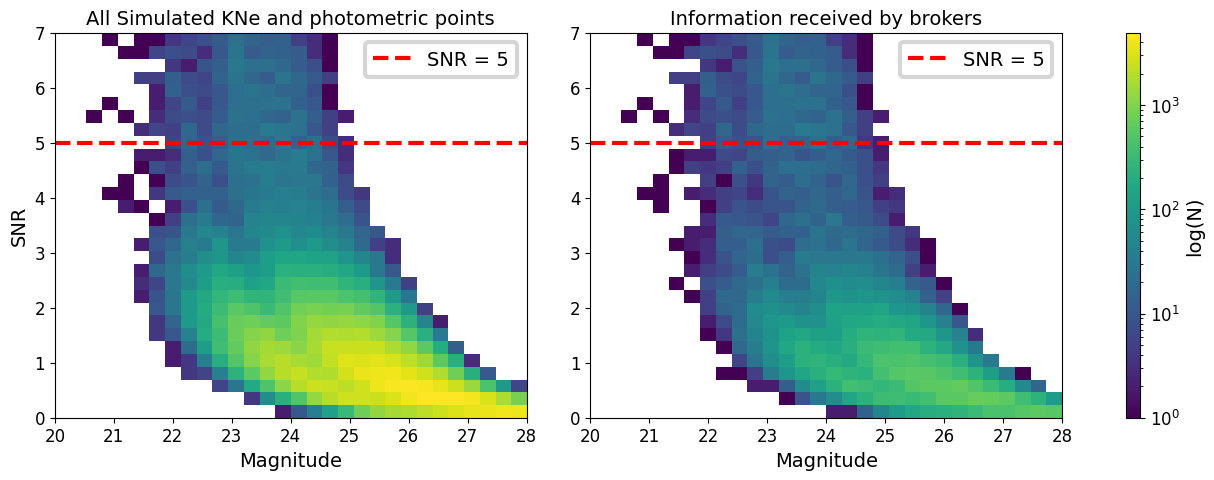

In [14]:
# SNR vs magnitude

# Define bins and ranges
x_bins = 30
y_bins = 30
x_range = [20, 28]
y_range = [0, 7]
bins = [x_bins, y_bins]
range_ = [x_range, y_range]

# Compute 2D histograms manually
H1, _, _ = np.histogram2d(df_phot['magnitude'], df_phot['SNR'],
                          bins=bins, range=range_)
H2, _, _ = np.histogram2d(df_phot[df_phot['SNID'].isin(snids_all_snr_gt5)]['magnitude'], df_phot[df_phot['SNID'].isin(snids_all_snr_gt5)]['SNR'],
                          bins=bins, range=range_)

# Determine global vmin and vmax for LogNorm (exclude zeros)
nonzero_counts = np.concatenate([H1.ravel(), H2.ravel()])
nonzero_counts = nonzero_counts[nonzero_counts > 0]
vmin = nonzero_counts.min()
vmax = nonzero_counts.max()

# Create figure with 3 subplots: 2 main plots + 1 thin colorbar subplot
fig = plt.figure(figsize=(14, 5))
gs = GridSpec(1, 3, width_ratios=[1, 1, 0.03], wspace=0.2)

# First heatmap (left)
ax1 = fig.add_subplot(gs[0])
im1 = ax1.imshow(H1.T, origin='lower',
                 extent=[*x_range, *y_range],
                 aspect='auto', cmap='viridis',
                 norm=LogNorm(vmin=vmin, vmax=vmax))
ax1.set_title('All Simulated KNe and photometric points')
ax1.set_xlabel('Magnitude')
ax1.set_ylabel('SNR')
ax1.axhline(y=5, color='r', linestyle='--', label='SNR = 5')
ax1.legend()

# Second heatmap (middle)
ax2 = fig.add_subplot(gs[1], sharey=ax1)
im2 = ax2.imshow(H2.T, origin='lower',
                 extent=[*x_range, *y_range],
                 aspect='auto', cmap='viridis',
                 norm=LogNorm(vmin=vmin, vmax=vmax))
ax2.set_title('Information received by brokers')
ax2.set_xlabel('Magnitude')
ax2.axhline(y=5, color='r', linestyle='--', label='SNR = 5')
ax2.legend()

# Colorbar subplot (right, very thin)
cax = fig.add_subplot(gs[2])
cbar = fig.colorbar(im2, cax=cax)
cbar.set_label('log(N)')

plt.tight_layout()
plt.show()


# With Alert in broker

/Users/amoller/Science/KN_OzGrav/KNcand_LVK/Rubin_KNe_with_Fink_LVK/myutils/all_utils.py:578: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(second_alert_range)
/Users/amoller/Science/KN_OzGrav/KNcand_LVK/Rubin_KNe_with_Fink_LVK/myutils/all_utils.py:578: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(second_alert_range)


SNID 6216_Kasen z=0.05
SNID 23118_Bulla z=0.07
SNID 8896_Kasen z=0.11


/Users/amoller/Science/KN_OzGrav/KNcand_LVK/Rubin_KNe_with_Fink_LVK/myutils/all_utils.py:578: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(second_alert_range)
/Users/amoller/Science/KN_OzGrav/KNcand_LVK/Rubin_KNe_with_Fink_LVK/myutils/all_utils.py:578: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(second_alert_range)


SNID 18107_Bulla z=0.03
SNID 15892_Bulla z=0.09


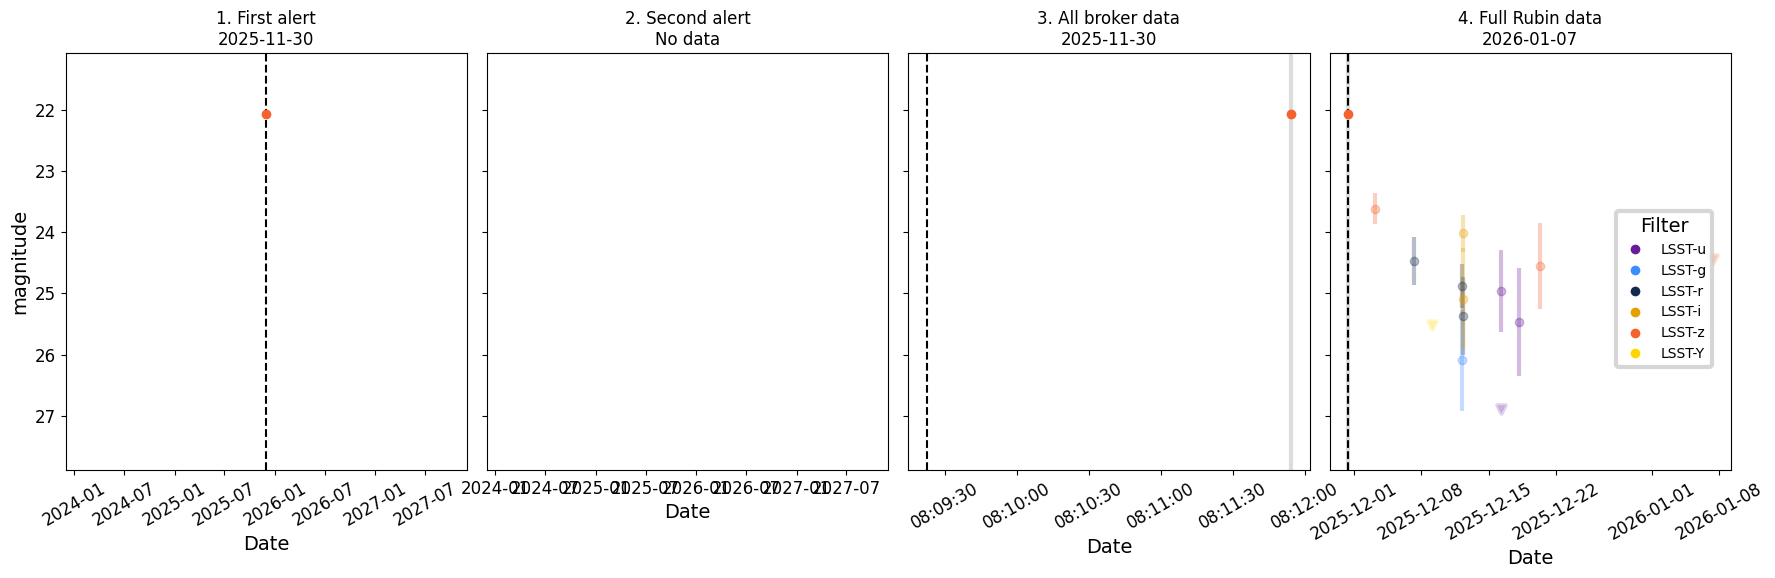

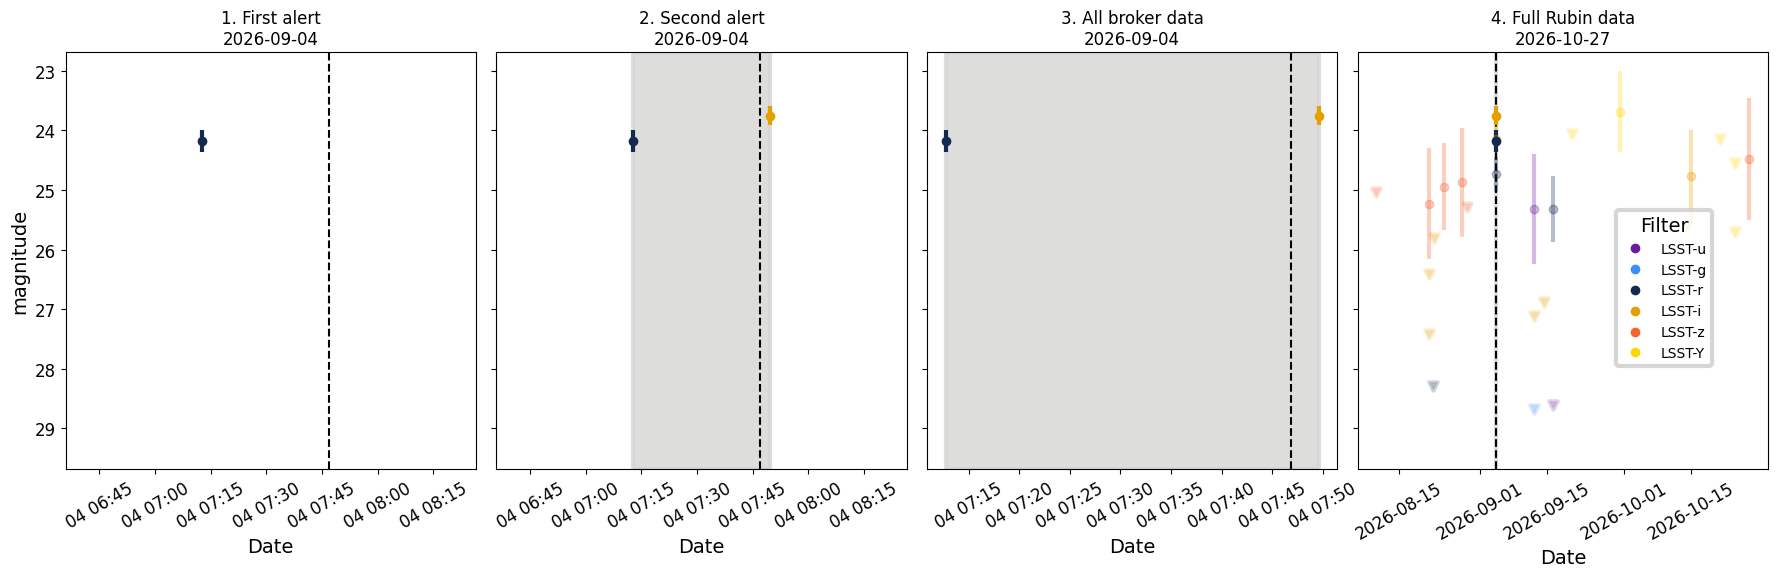

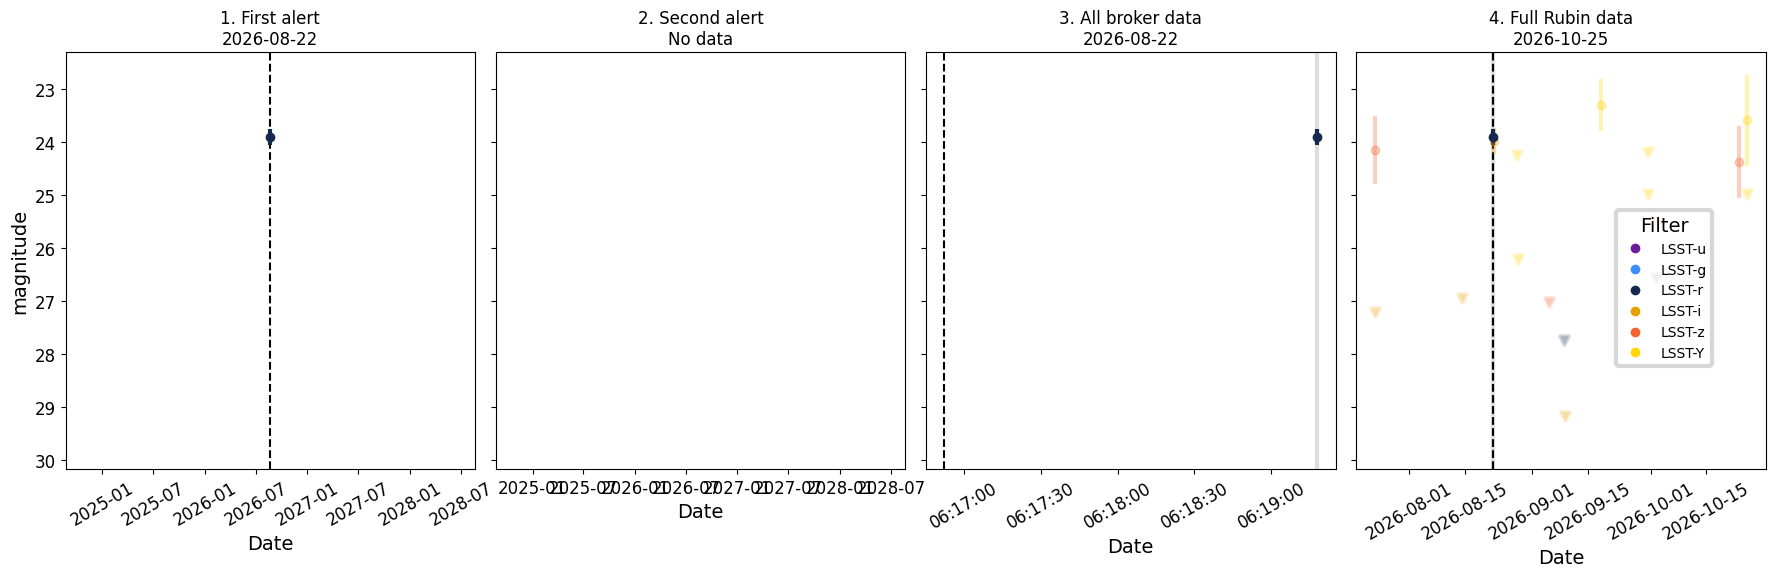

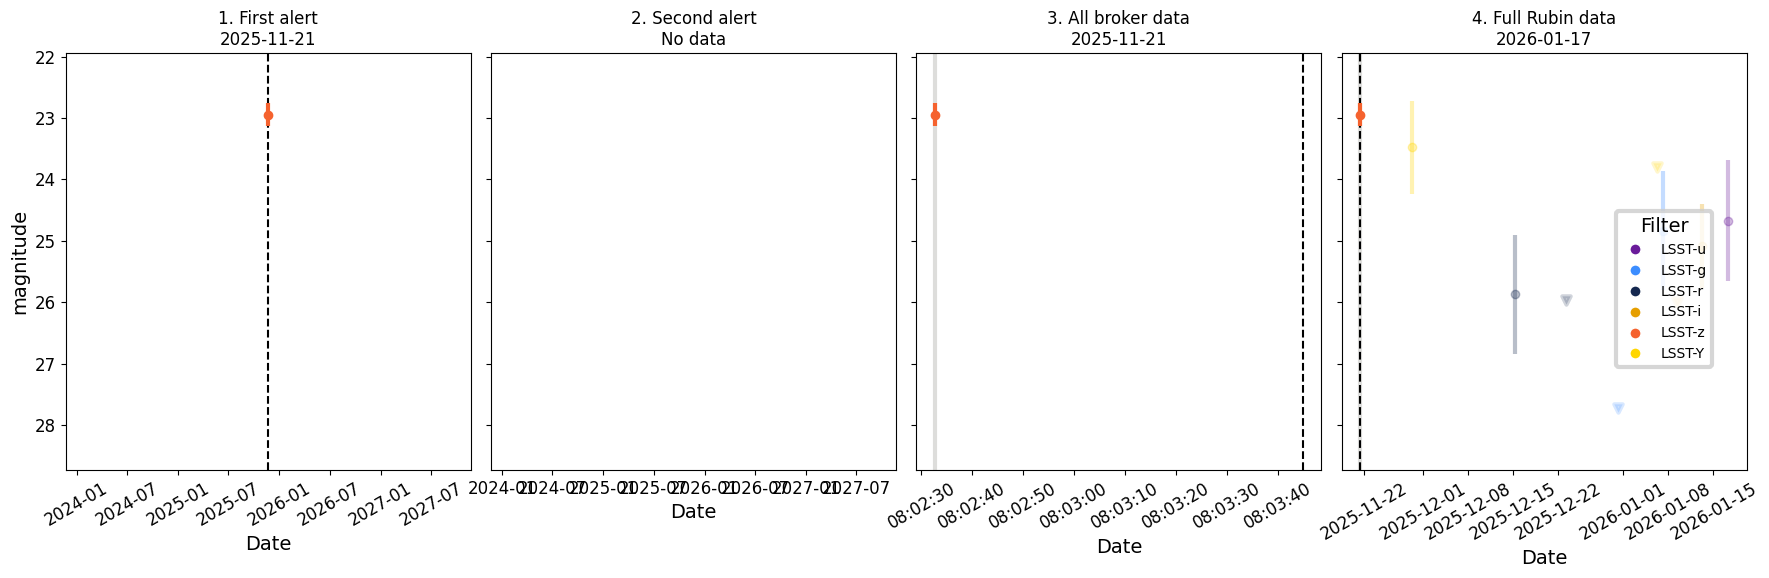

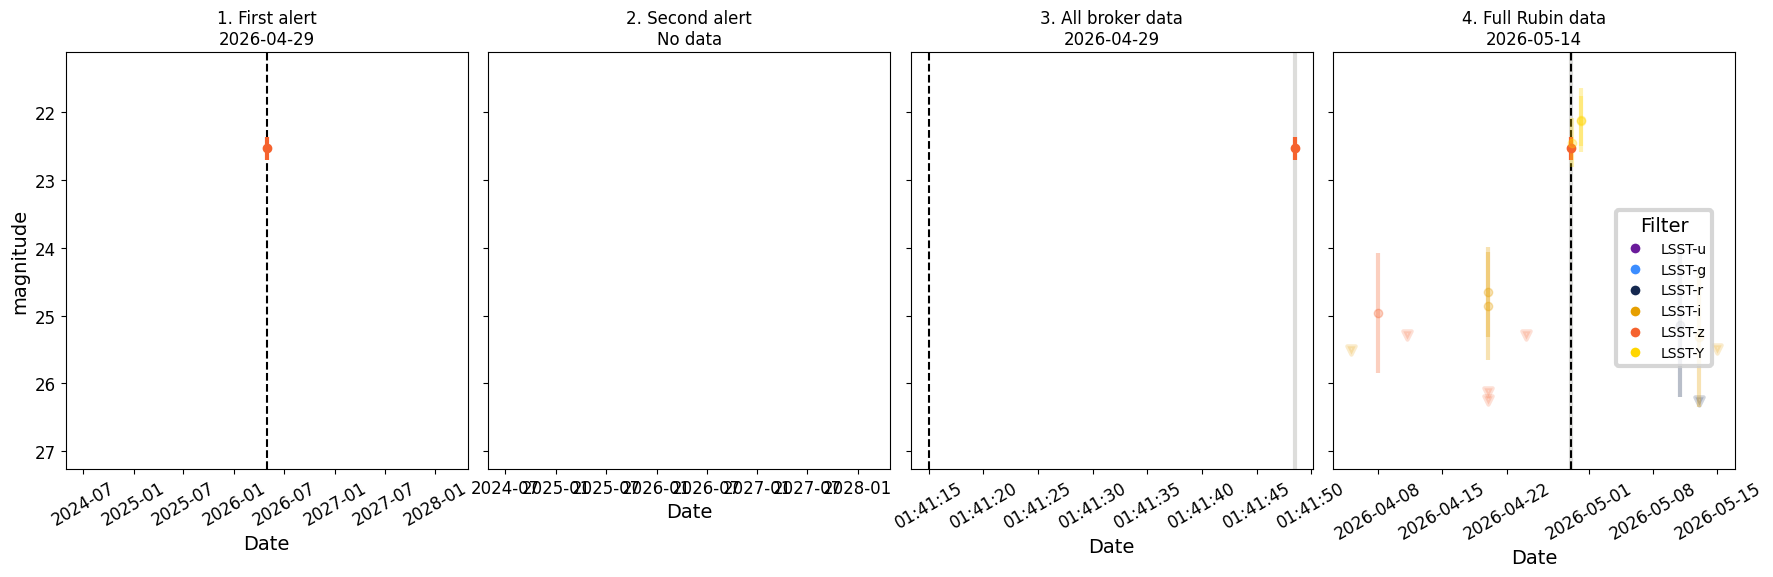

In [15]:
for idx in list(set(snids_all_snr_gt5))[:5]:
    # plot_lc_subplots(df_phot,df_header, idx, inmag=True,convert_date=True)
    au.plot_lc_subplots_matplotlib(df_phot, df_header, idx, inmag=True, convert_date=True)


# Best sampling

In [16]:
top_10_snids_by_magnitude_count = (
    df_phot[(df_phot['magnitude'].notnull()) & (df_phot['SNR']>5)]
    .groupby('SNID')
    .size()
    .sort_values(ascending=False)
    .head(15)
)


SNID 3021_Bulla z=0.03
SNID 3021_Kasen z=0.03
SNID 9575_Kasen z=0.04
SNID 8943_Bulla z=0.02
SNID 15933_Kasen z=0.06
SNID 16907_Kasen z=0.04
SNID 8943_Kasen z=0.02
SNID 8220_Bulla z=0.08
SNID 10510_Bulla z=0.02
SNID 19090_Kasen z=0.05
SNID 8220_Kasen z=0.08
SNID 15926_Kasen z=0.06
SNID 11641_Kasen z=0.04
SNID 19802_Bulla z=0.03
SNID 2739_Kasen z=0.02


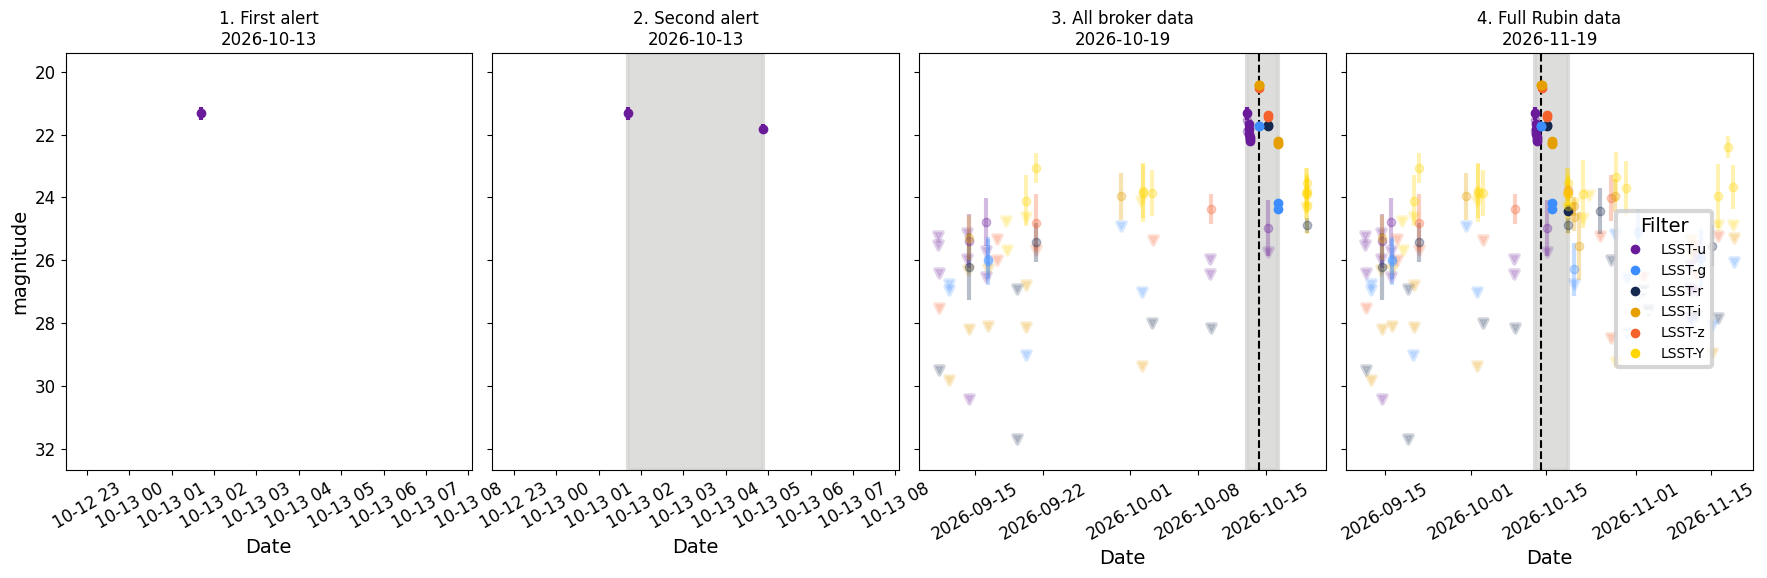

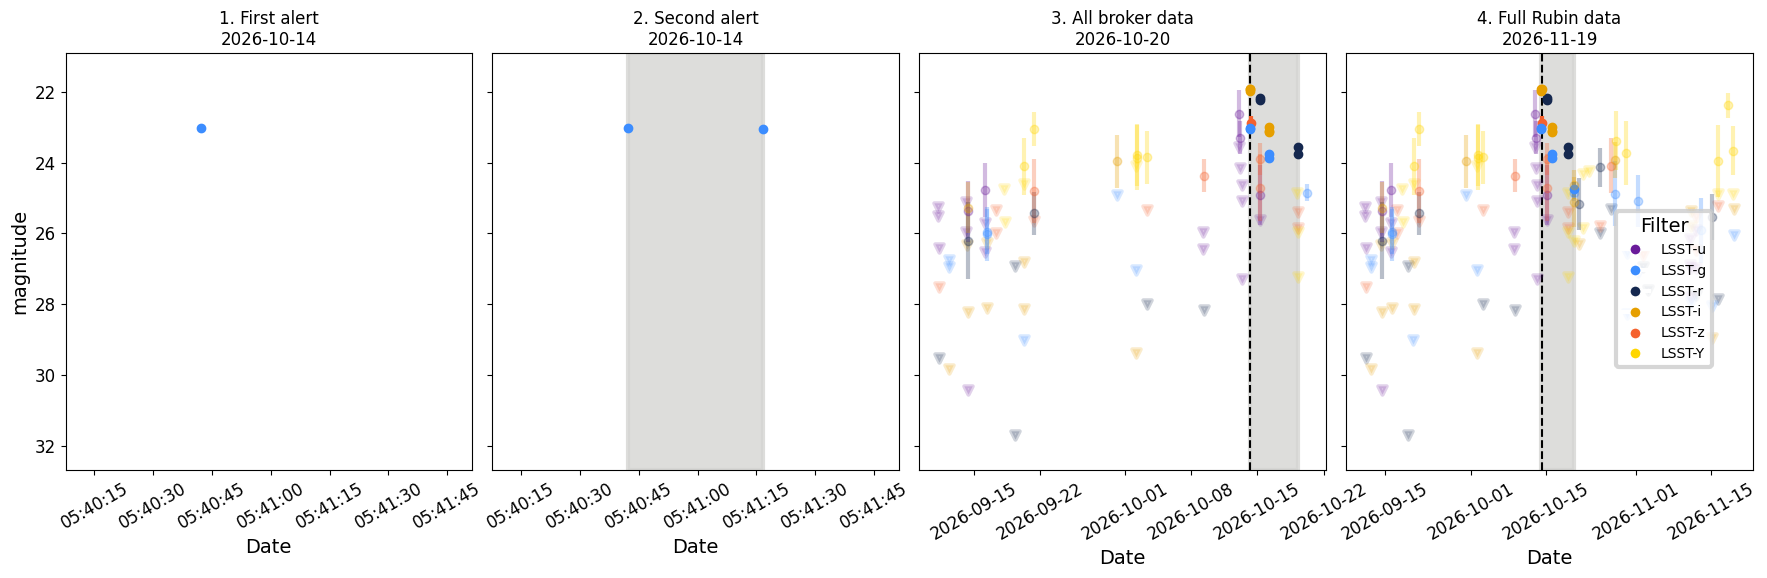

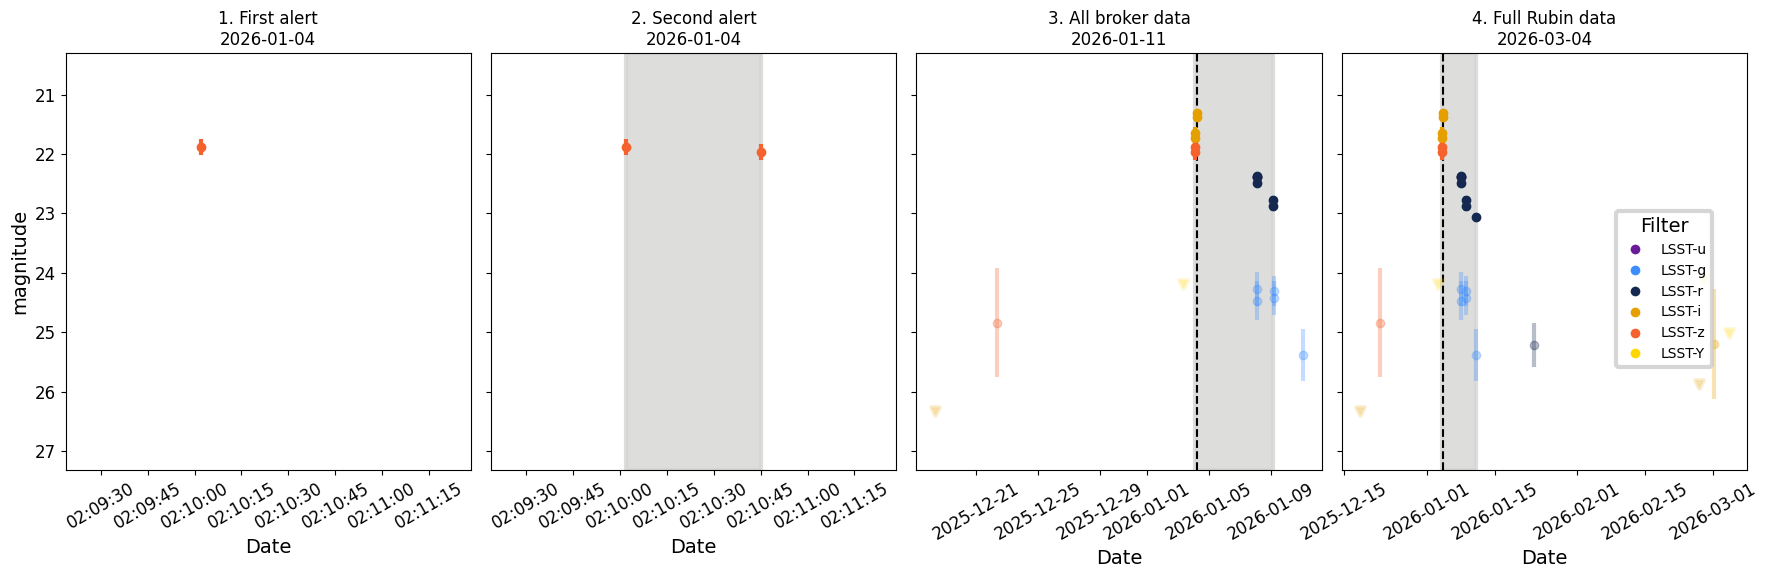

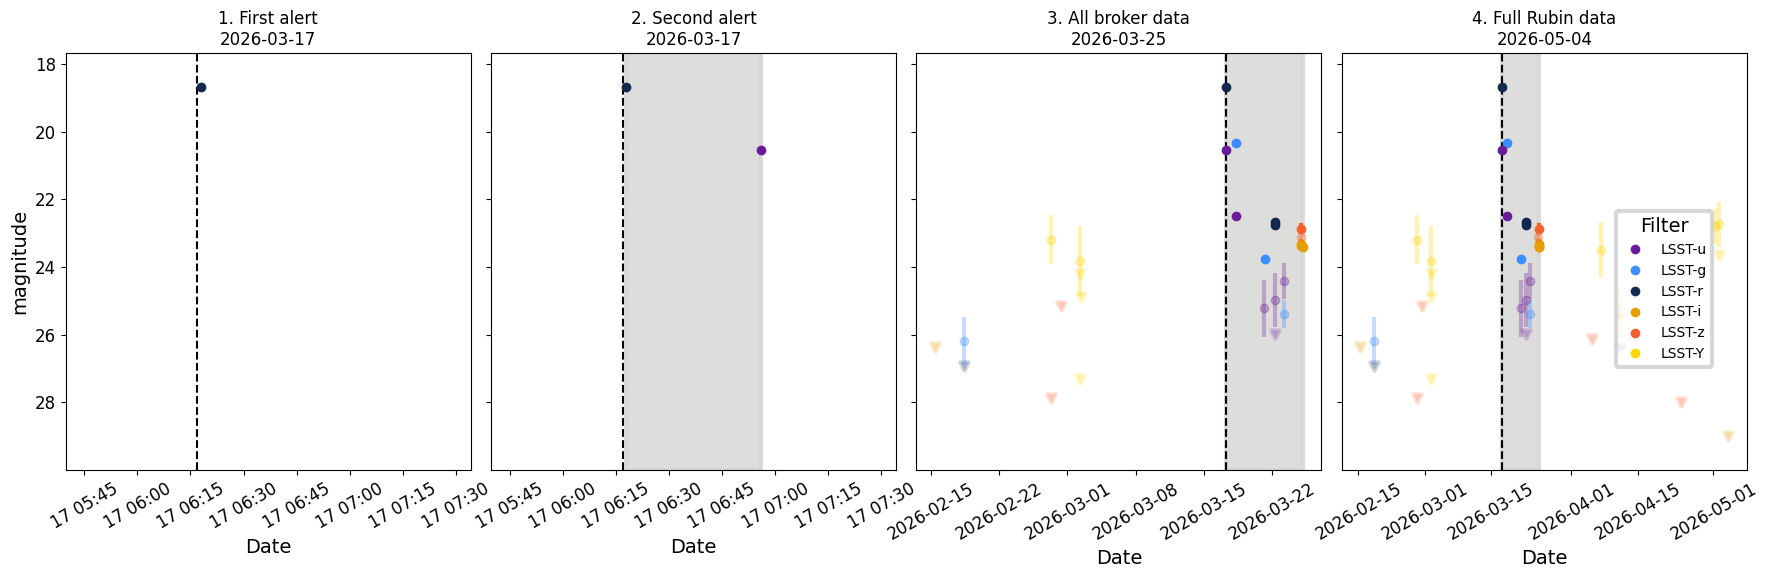

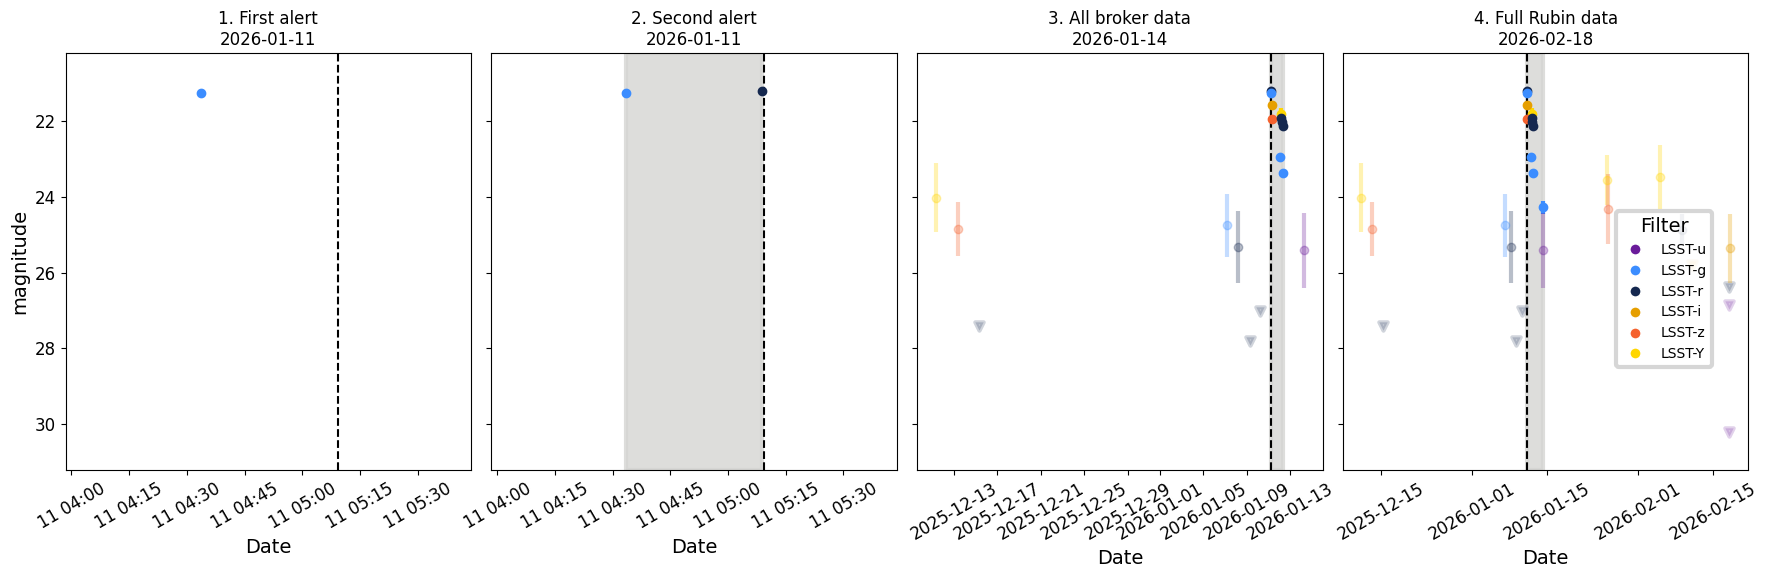

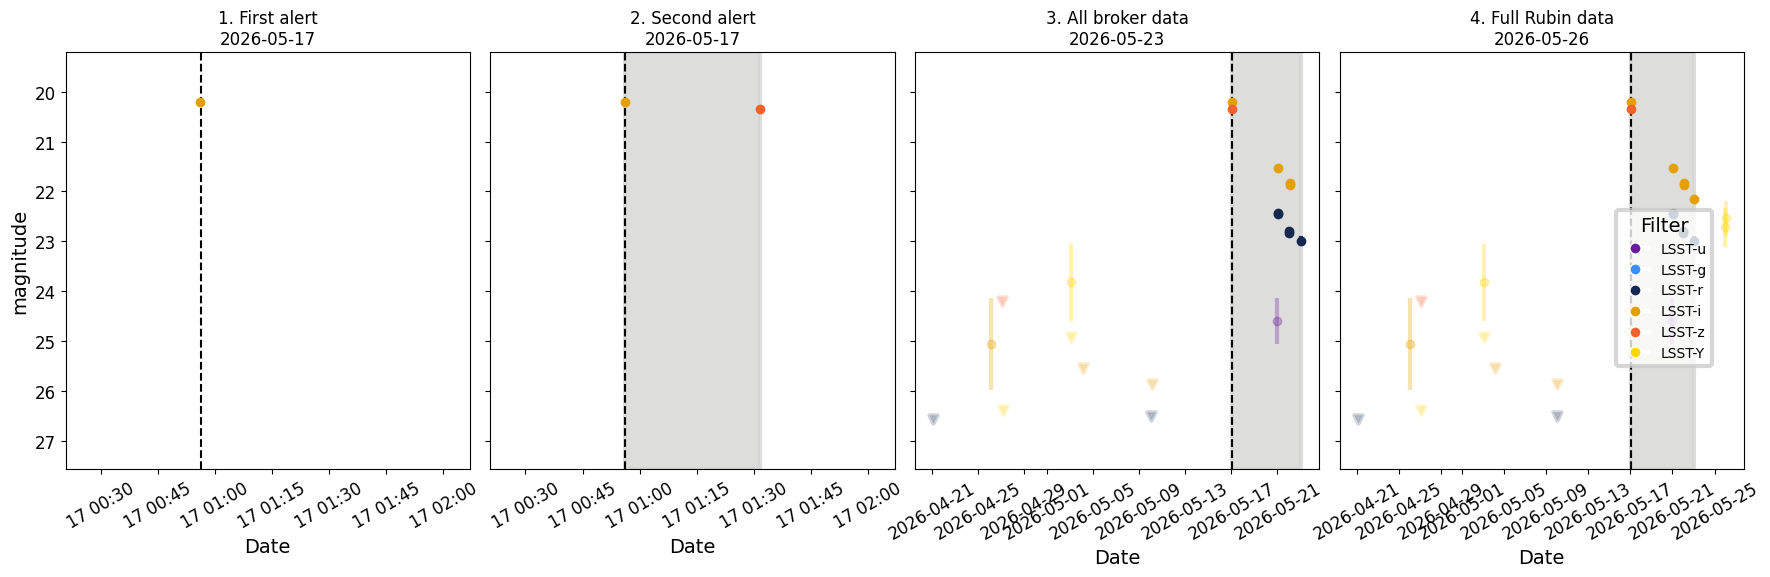

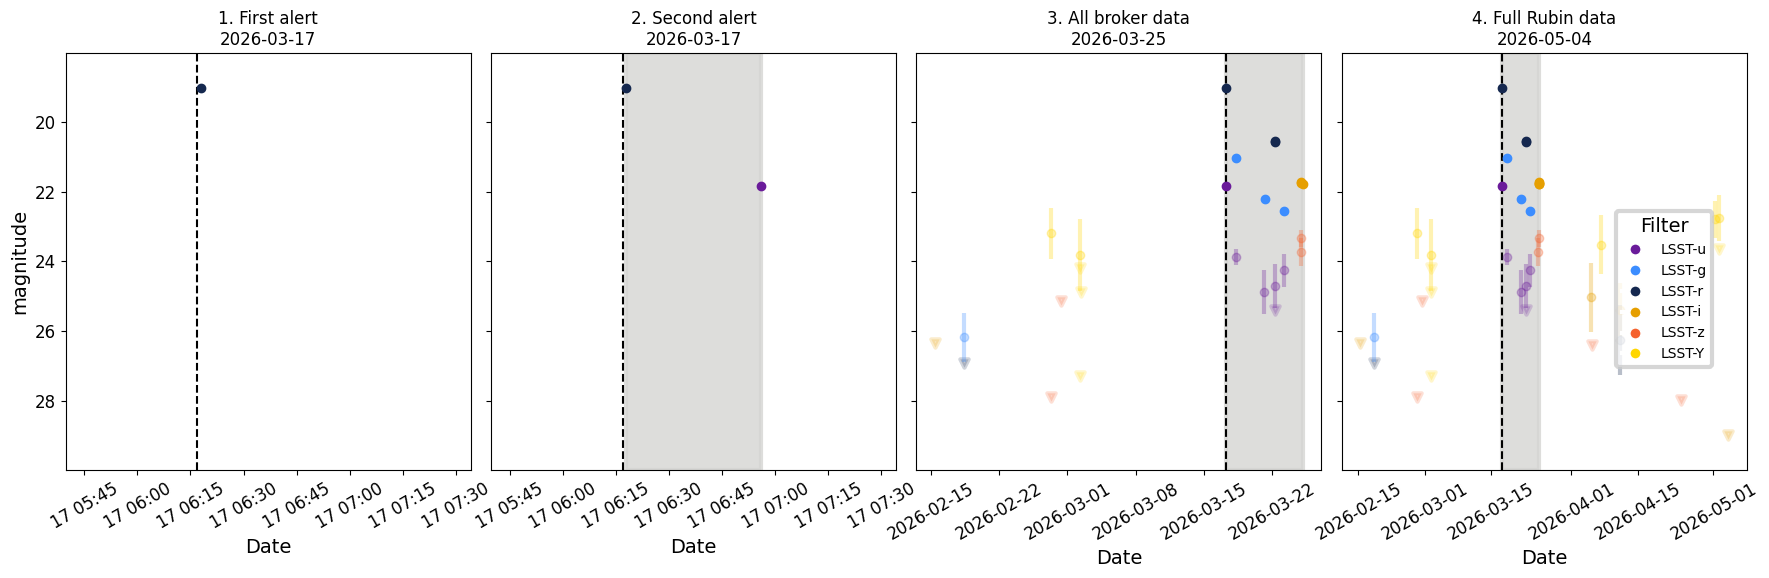

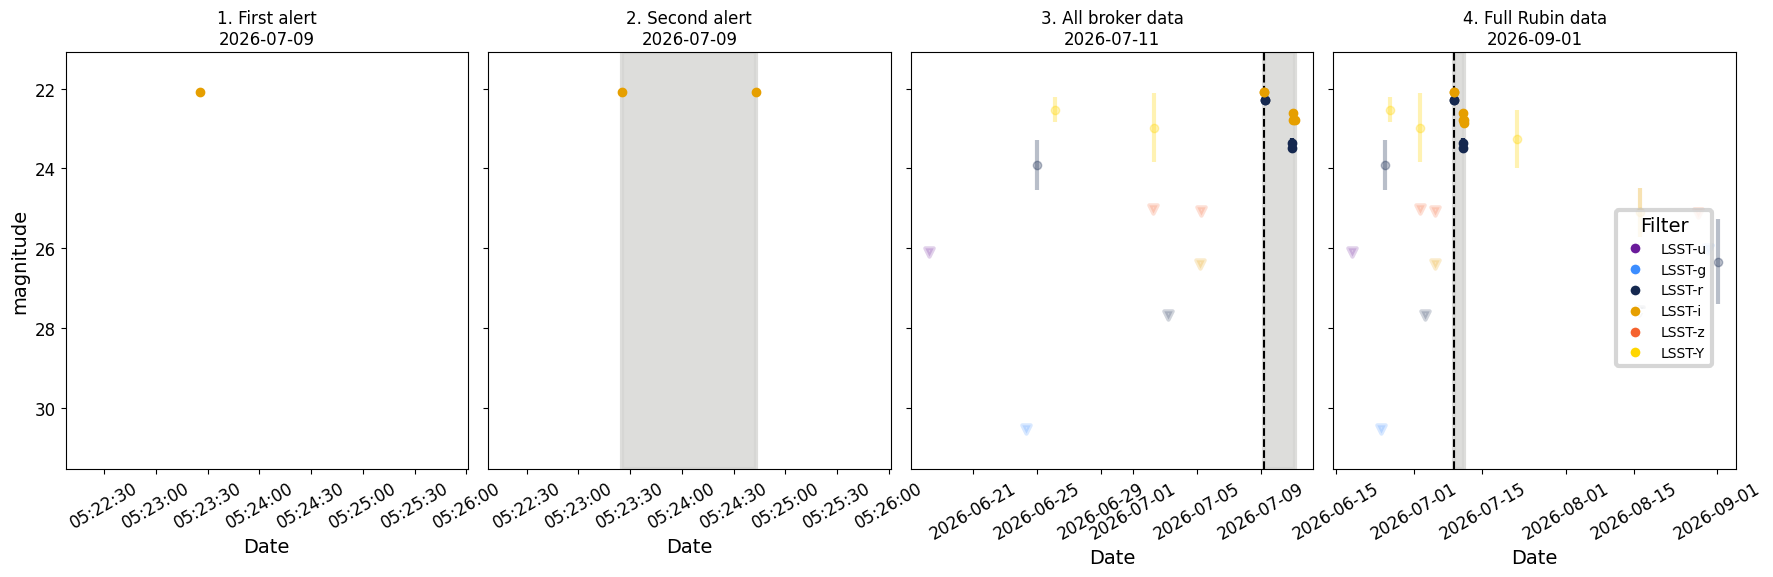

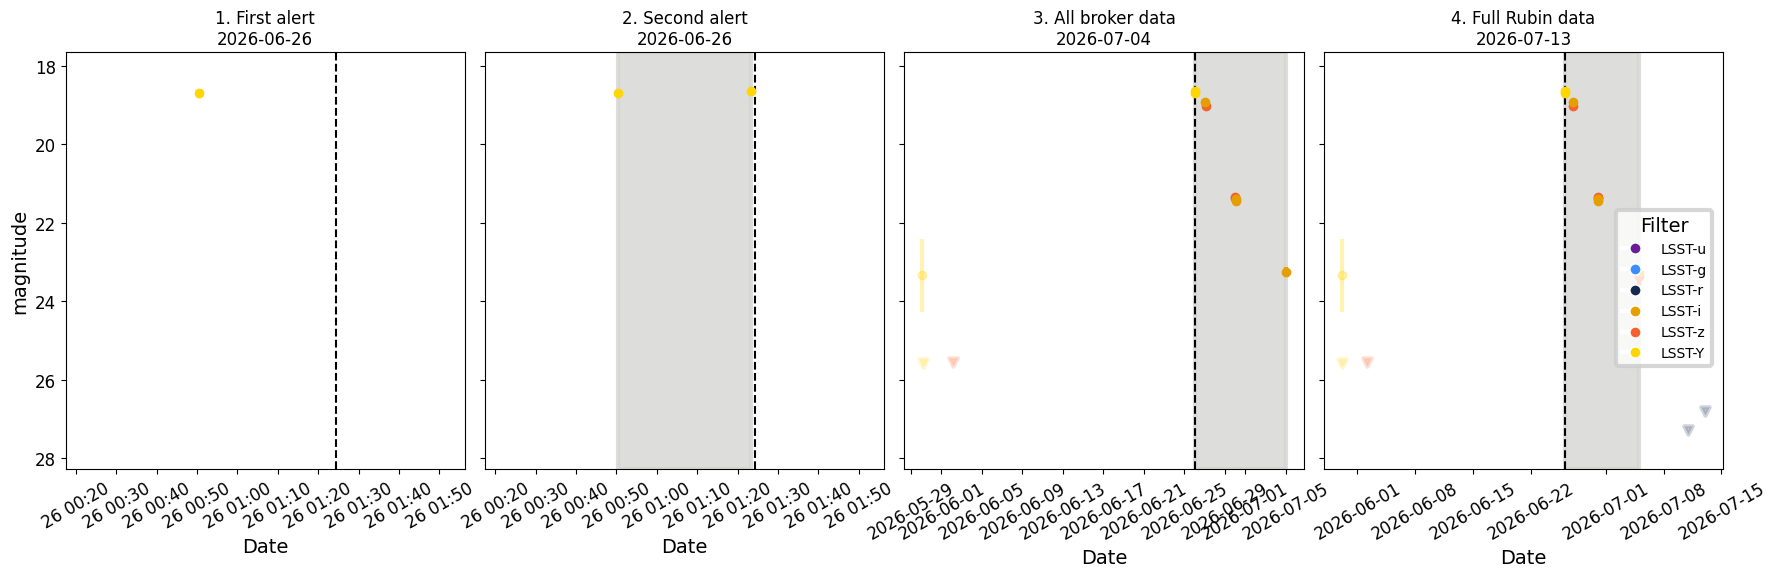

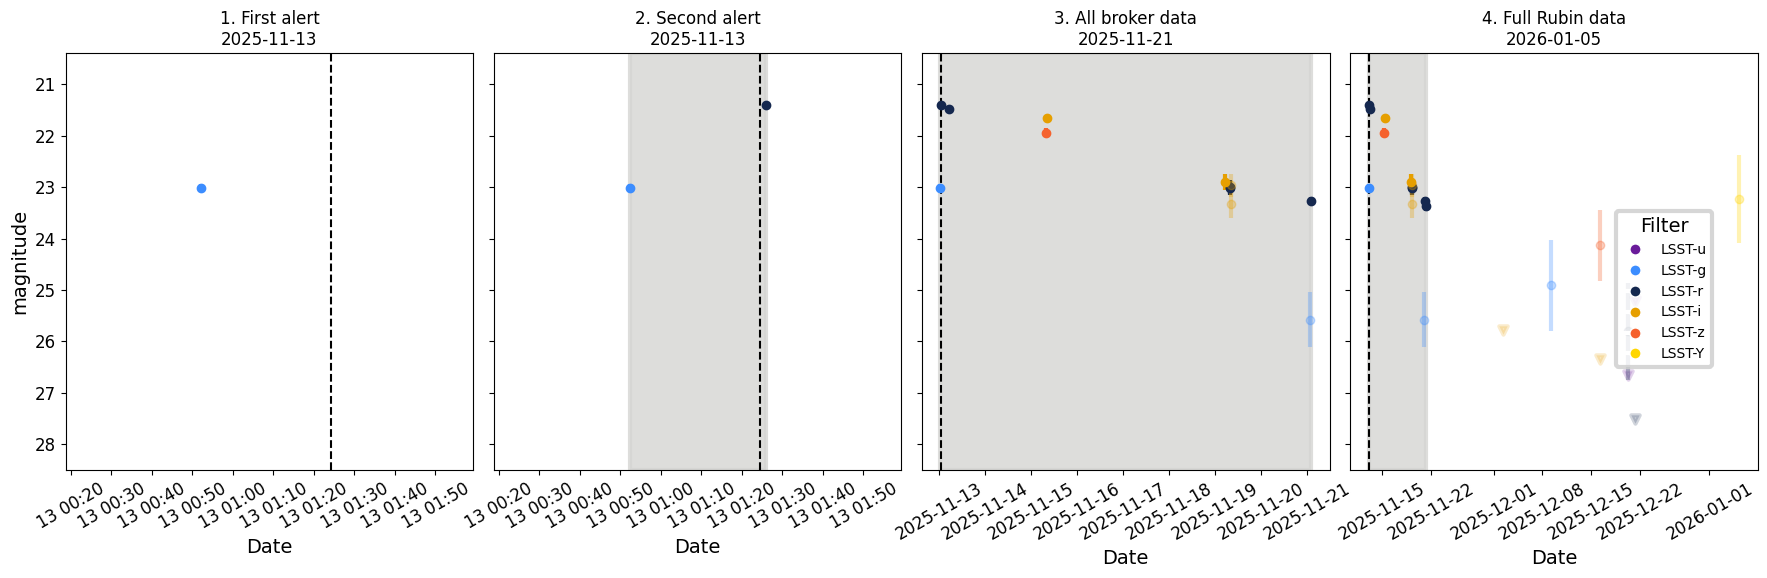

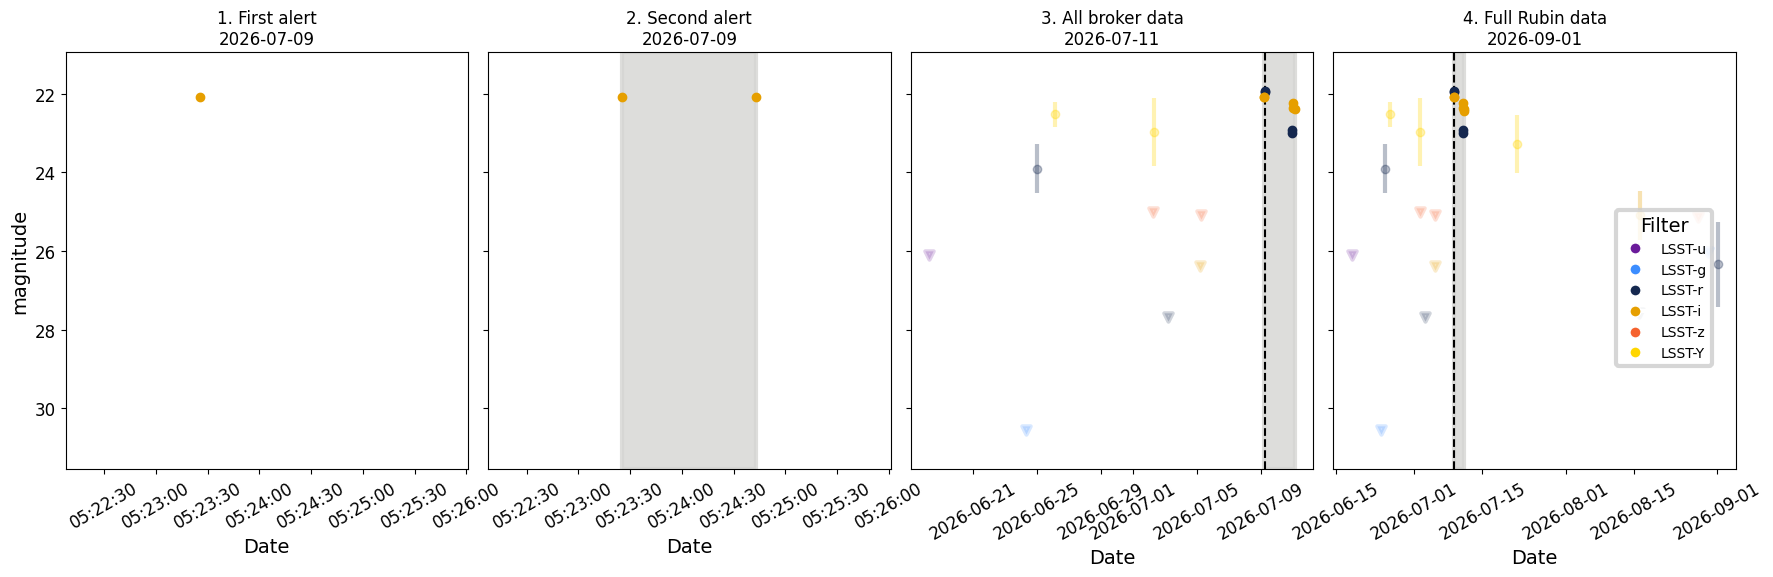

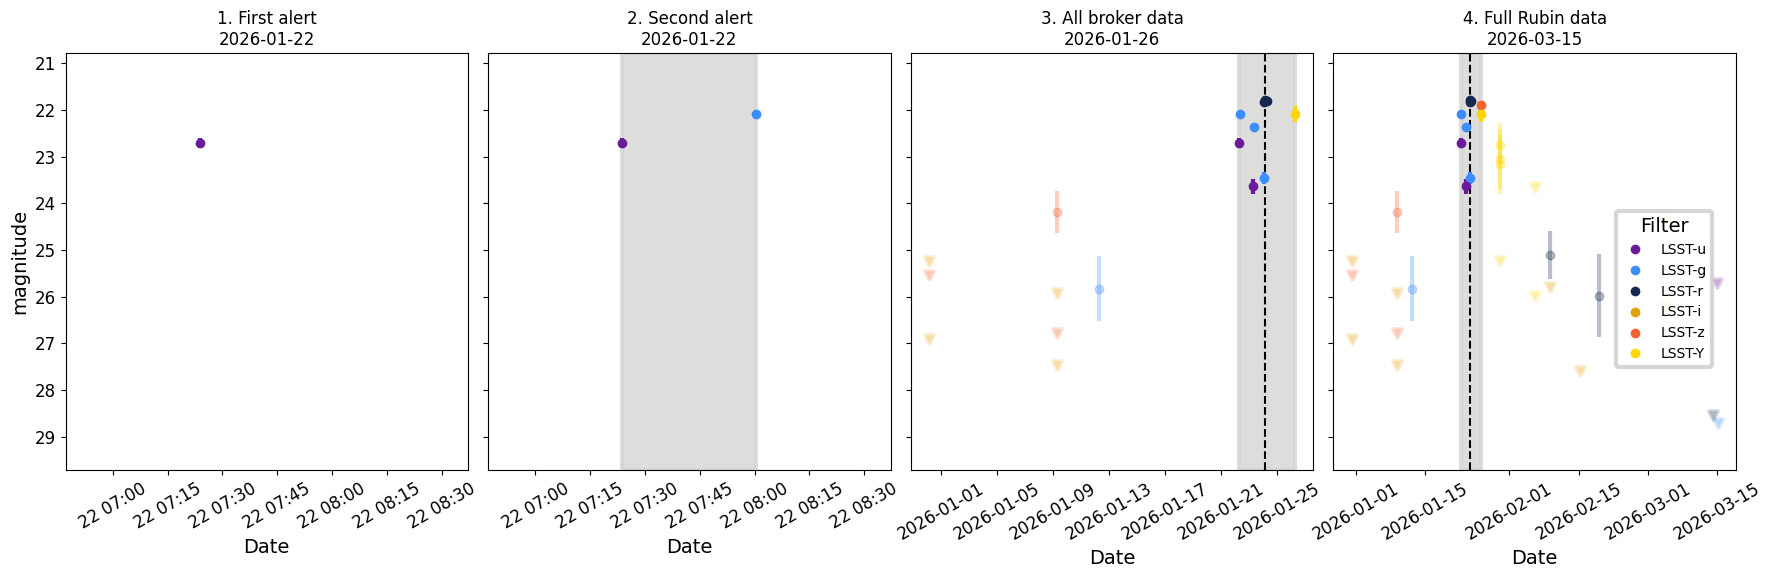

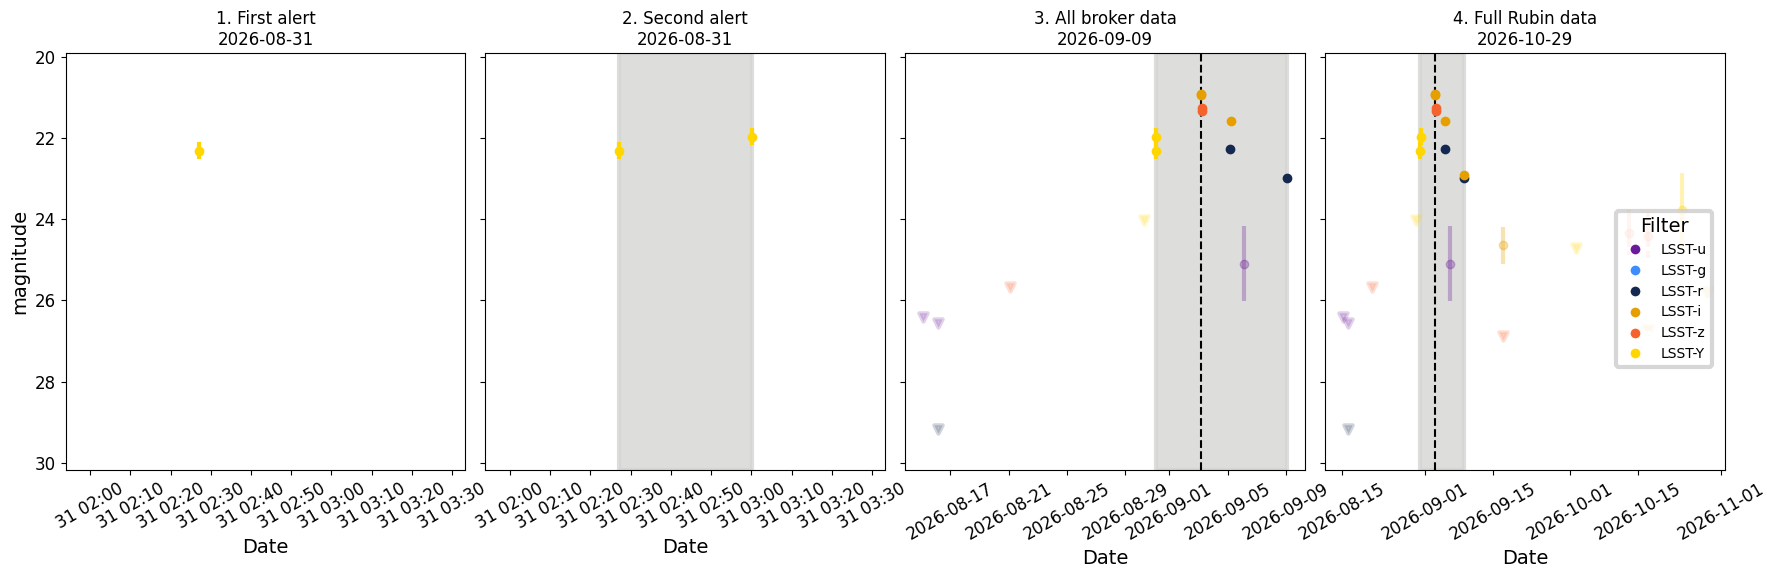

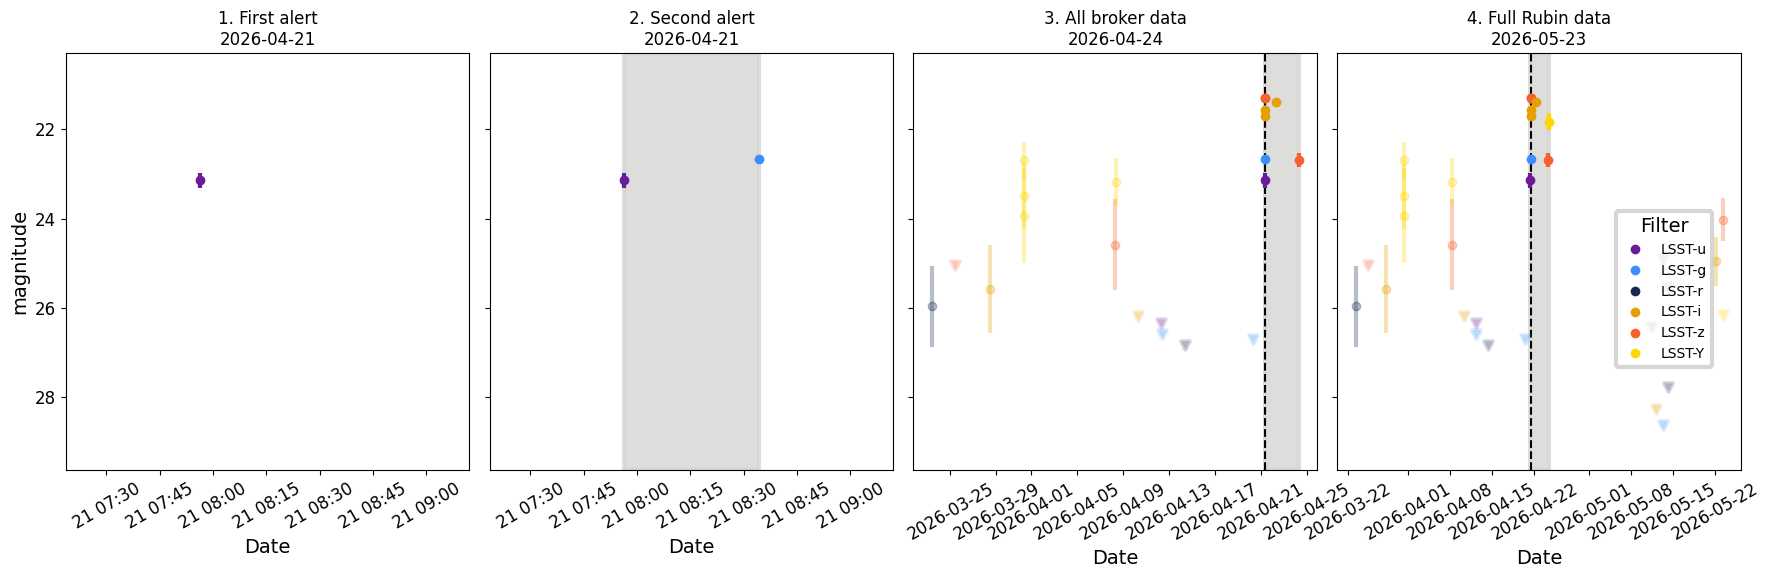

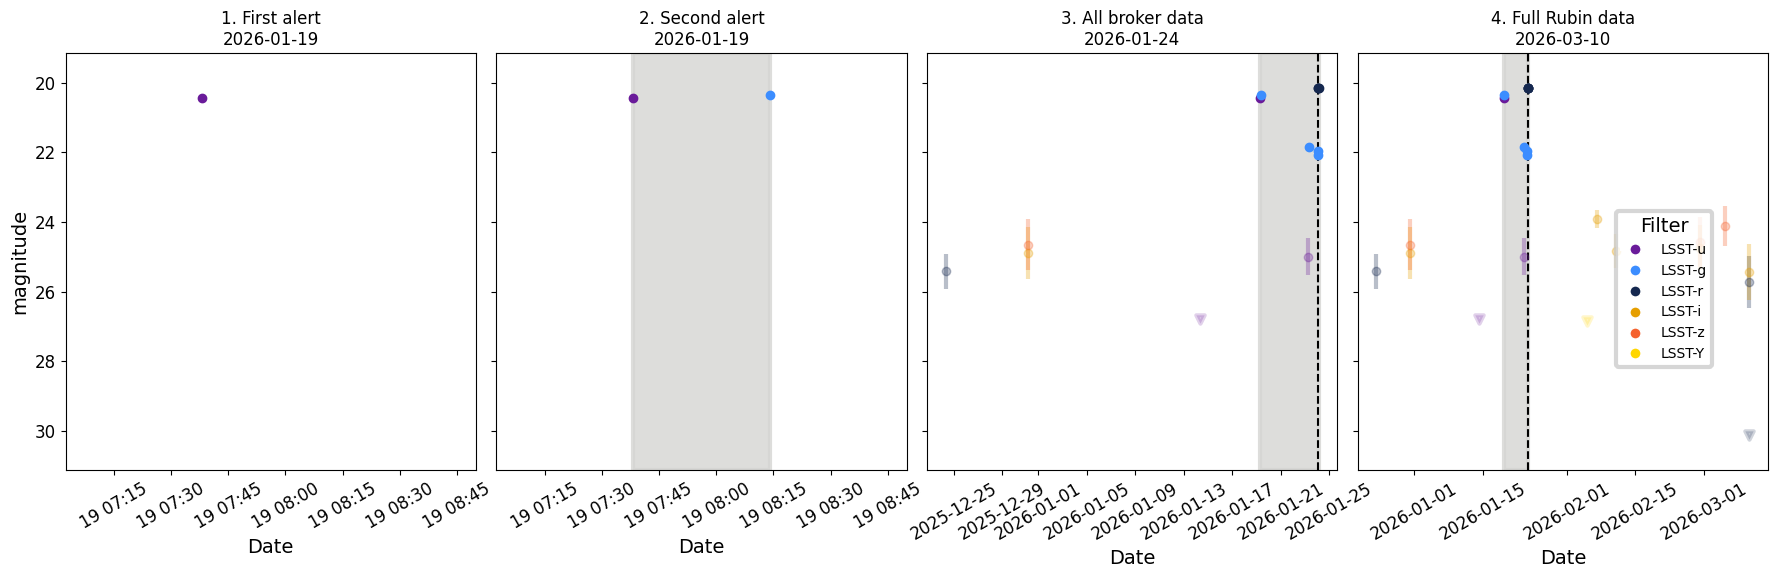

In [ ]:
for idx in top_10_snids_by_magnitude_count.index:
    # plot_lc_subplots(df_phot,df_header, idx, inmag=True,convert_date=True)
    au.plot_lc_subplots_matplotlib(df_phot, df_header, idx, inmag=True, convert_date=True, savefig=True)

# DDF + at least one detection in broker

# How early are we detecting them?

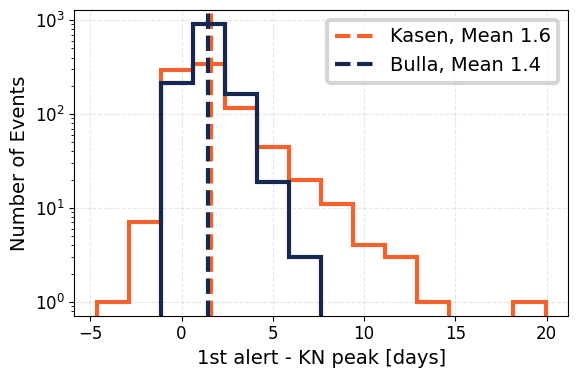

In [18]:
# Filter to SNR > 5 detections
snr5 = df_phot[df_phot['SNR'] > 5].copy()

# Get first MJD with SNR > 5 per SNID
first_snr5 = snr5.groupby('SNID')['MJD'].min().rename('first_snr5_mjd')

# Merge with header to align with PEAKMJD
df_header_w1stsnr5 = df_header.merge(first_snr5, on='SNID', how='left')

# Compute signed difference: PEAK - first SNR > 5
df_header_w1stsnr5['delta_snr5_peak'] = np.where(
    df_header_w1stsnr5['SIM_PEAKMJD'] > 0,
    df_header_w1stsnr5['first_snr5_mjd'] - df_header_w1stsnr5['SIM_PEAKMJD'],
    np.nan
)

# Histogram bins
bins = np.linspace(df_header_w1stsnr5['delta_snr5_peak'].min(), df_header_w1stsnr5['delta_snr5_peak'].max(), 15) 

plt.figure(figsize=(6, 4))

for typ in df_header_w1stsnr5.SIM_GENTYPE.unique():
    # Filter headers for current SN type
    sel_header = df_header_w1stsnr5[(df_header_w1stsnr5.SIM_GENTYPE == typ)].copy()
    
    # Drop NaNs
    data_snr5 = sel_header['delta_snr5_peak'].dropna()
    
    # Choose color per type
    color = au.dic_KN_models_colors[au.dic_sntype[str(typ)]]
    
    # Step histogram
    plt.hist(data_snr5, bins=bins, histtype='step', color=color)
    
    # Mean line
    mean_snr5 = data_snr5.mean()
    plt.axvline(mean_snr5, color=color, linestyle='dashed',
                label=f'{au.dic_sntype[str(typ)]}, Mean {mean_snr5:.1f}')
    
plt.xlabel('1st alert - KN peak [days]')
plt.ylabel('Number of Events')
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f'{path_plots}/first_alert_vs_peak.png')

Kasen 0.011900000001332955 2.6570354156363987
Kasen 0.01209999999991851 2.4616750243375676
Bulla 0.011700000002747402 0.817300239185114
Bulla 0.002599999999802094 1.841402015313404


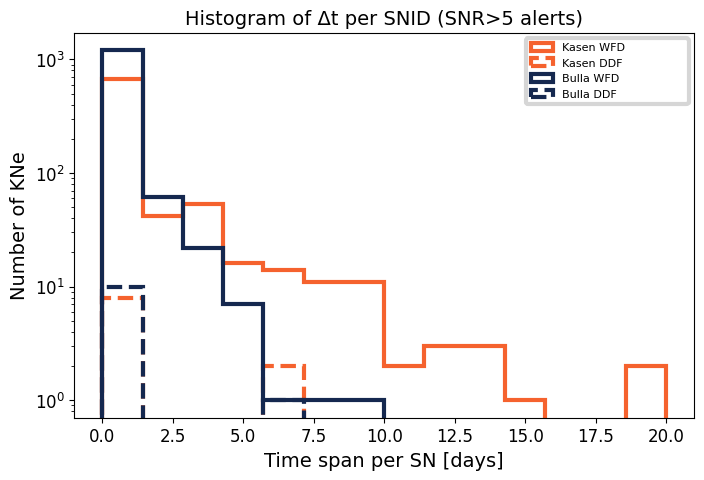

In [25]:
plt.figure(figsize=(8,5))
mybins = np.linspace(0, 20, 15)  # Adjust bins as needed

for mod in snr5['model_name'].unique():
    for f in snr5['FIELD'].unique():
        sel = snr5[(snr5['model_name'] == mod) & (snr5['FIELD'] == f)]
        if len(sel) == 0:
            continue
        
        # compute delta_times for this group only
        delta_times_group = sel.groupby("SNID")["MJD"].agg(lambda x: x.max() - x.min())
        
        # handle bytes or str
        f_str = f.decode() if isinstance(f, bytes) else f
        linestyle = '-' if 'WFD' in f_str else '--'
        plt.hist(delta_times_group, bins=mybins, histtype='step', color=dic_KN_models_colors.get(mod, 'k') , linestyle=linestyle, label=f"{mod} {f_str}")
        median_val = delta_times_group.median()
        print(mod,median_val,std_val := delta_times_group.std())

plt.xlabel("Time span per SN [days]")
plt.ylabel("Number of KNe")
plt.yscale("log")
plt.title("Histogram of Δt per SNID (SNR>5 alerts)")
plt.legend(fontsize=8)
plt.show()


In [26]:
# mydelta = snr5.groupby("SNID")["MJD"].agg(lambda x: x.max() - x.min())
# idxs = mydelta[mydelta>10].index
# for idx in idxs:
#     plot_lc_subplots_matplotlib(df_phot, df_header, idx, inmag=True, convert_date=True)


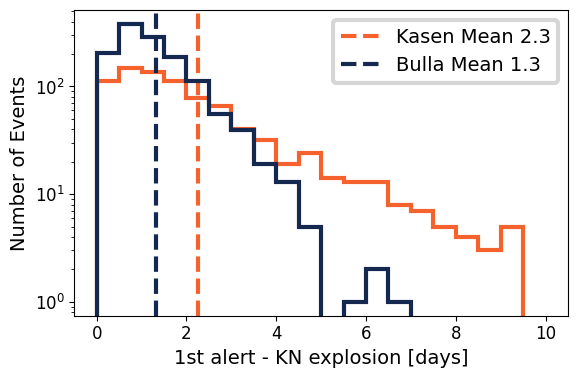

In [19]:
   
plt.figure(figsize=(6, 4))
bins = np.linspace(0, 10, 21)  # 10 bins between 0 and 10

for typ in df_header.SIM_GENTYPE.unique():
    sel_header = df_header_w1stsnr5[df_header_w1stsnr5.SIM_GENTYPE == typ].copy()
    sel = df_phot[df_phot.SNID.isin(sel_header.SNID)]
    
    # Compute delta between peak and explosion
    sel_header['delta_firstalert_explode'] = sel_header['first_snr5_mjd'] - sel_header['SIM_MJD_EXPLODE']

    # Choose color per type
    color = au.dic_KN_models_colors[au.dic_sntype[str(typ)]]
    
    # All events (dashed step)
    # plt.hist(data_all, bins=bins, histtype='step', linestyle='dashed', color=color,linewidth=1.5)
    
    # SNR>5 events (solid step)
    plt.hist(sel_header['delta_firstalert_explode'], bins=bins, histtype='step', color=color)

    mean_snr = sel_header['delta_firstalert_explode'].mean()
    plt.axvline(mean_snr, color=color, linestyle='dashed', 
                label=f'{au.dic_sntype[str(typ)]} Mean {mean_snr:.1f}')

plt.xlabel('1st alert - KN explosion [days]')
plt.ylabel('Number of Events')
plt.legend()
plt.yscale('log')
plt.tight_layout()
plt.savefig(f'{path_plots}/first_alert_vs_explosion.png')
plt.show()


# How bright?

In [23]:
idx_max_flux = df_phot.groupby(['SNID', 'BAND'])['FLUXCAL'].idxmax()
df_max_flux = df_phot.loc[idx_max_flux].reset_index(drop=True)
# df_max_flux

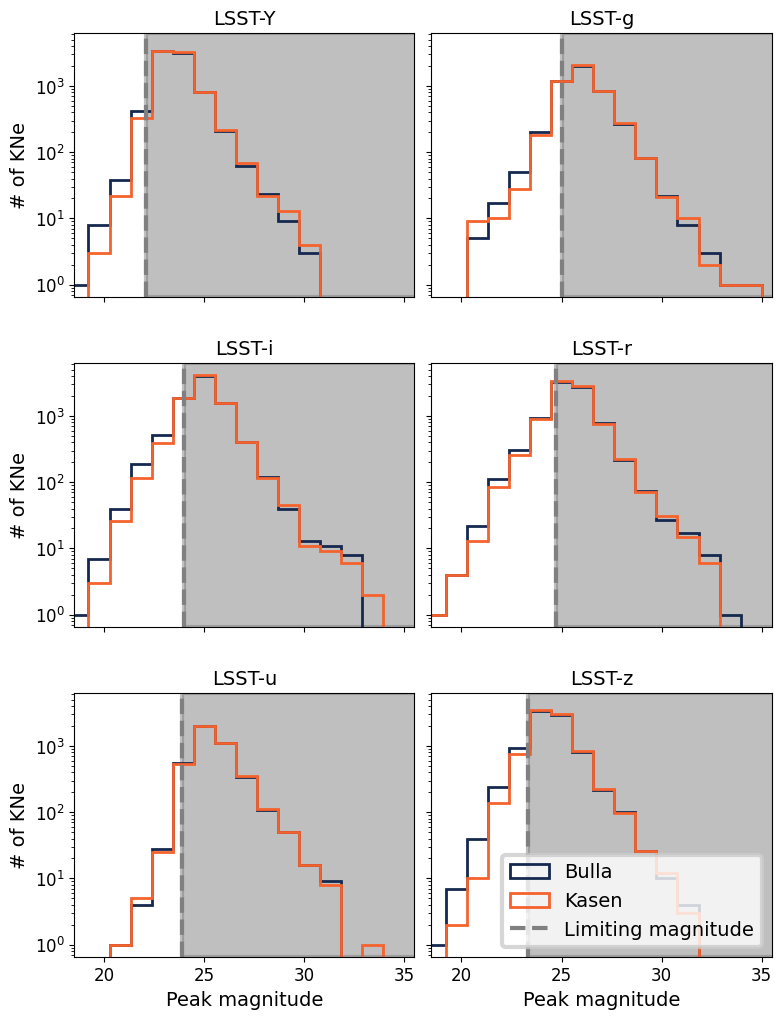

In [46]:
fig, axes = plt.subplots(3, 2, figsize=(9, 12), sharey=True, sharex=True)
plt.subplots_adjust(wspace=0.05, hspace=0.25)

mybins = np.linspace(15, 35, 20)  # Bins for histogram

axes = axes.flatten()  # flatten 3x2 grid into 1D array for easy looping
bands = sorted(df_phot['BAND'].unique())  # sorted to control order

for ax, flt in zip(axes, bands):
    ax.set_title(flt)
    for mod in ['Bulla', 'Kasen']:
        sel_max_flux = df_max_flux[
            (df_max_flux['model_name'] == mod) &
            (df_max_flux['BAND'] == flt)
        ]
        ax.hist(
            sel_max_flux['magnitude'],
            bins=mybins,
            label=mod,
            color=au.dic_KN_models_colors[mod],
            histtype='step',
            linewidth=2,
        )

    # vertical line + shaded region
    ax.axvline(x=au.dic_limiting_mags[flt], color='grey', linestyle='--', label='Limiting magnitude')
    ax.axvspan(au.dic_limiting_mags[flt], ax.get_xlim()[1], color='grey', alpha=0.5)

axes[4].set_xlabel("Peak magnitude")
axes[5].set_xlabel("Peak magnitude")

# shared y-label
axes[0].set_ylabel("# of KNe")
axes[2].set_ylabel("# of KNe")  # also label the 2nd row
axes[4].set_ylabel("# of KNe")  # also label the 3rd row

plt.yscale("log")
plt.xlim(18.5, 35.5)
plt.legend(loc='lower right')
plt.savefig(f'{path_plots}/hist_mags.png')
plt.show()

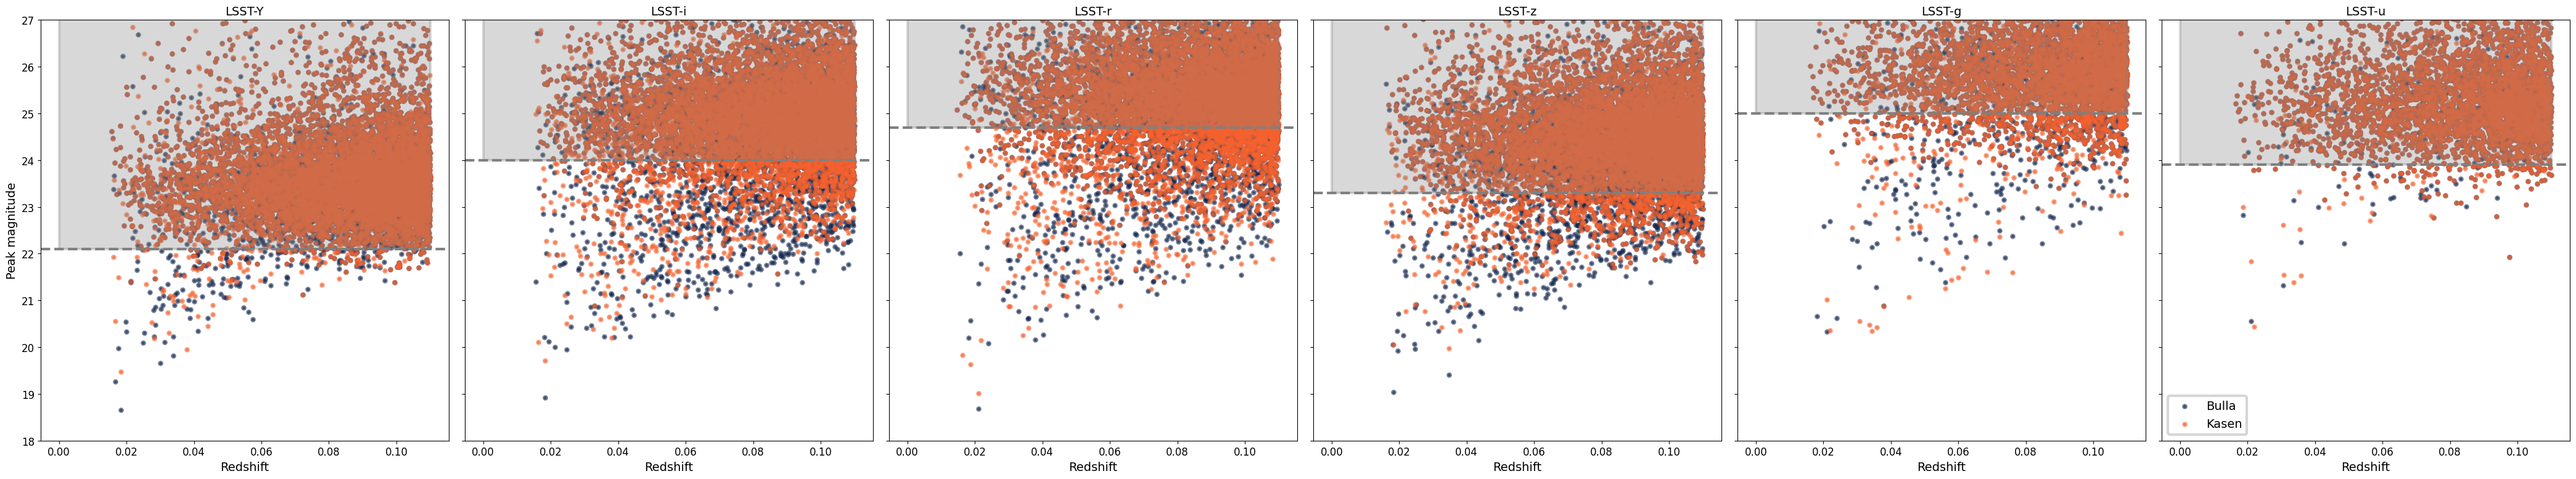

In [45]:
# Merge redshift into the max flux dataframe
df_with_z = df_max_flux.merge(
    df_header[['SNID', 'SIM_REDSHIFT_CMB']], 
    on='SNID', how='left'
)
bands = df_with_z['BAND'].unique()
fig, axes = plt.subplots(1, len(bands), figsize=(7*len(bands), 8), sharey=True, sharex=False)

for ax, flt in zip(axes, bands):
    ax.set_title(flt)
    for mod in ['Bulla', 'Kasen']:
        sel = df_with_z[
            (df_with_z['model_name'] == mod) &
            (df_with_z['BAND'] == flt)
        ]
        ax.scatter(
            sel['SIM_REDSHIFT_CMB'], sel['magnitude'],
            s=10, alpha=0.6,
            label=mod,
            color=au.dic_KN_models_colors[mod]
        )

    # limiting magnitude line (horizontal this time)
    ax.axhline(y=au.dic_limiting_mags[flt], color='grey', linestyle='--')
    ax.fill_between(
        [0, df_header['SIM_REDSHIFT_CMB'].max()],  # x-range
        au.dic_limiting_mags[flt],  # lower bound
        df_phot['magnitude'].max(),        # upper bound
        color='grey', alpha=0.3
    )
    ax.set_xlabel("Redshift")
    
axes[0].set_ylabel("Peak magnitude")
plt.ylim(18, 27)
plt.legend()
plt.tight_layout()
plt.show()


### is there a more predominant color we can use?

In [27]:
pairs = []
for snid, group in df_max_flux.groupby("SNID"):
    group = group.sort_values("MJD")

    for i, row1 in group.iterrows():
        for j, row2 in group.iterrows():
            if row1.BAND == row2.BAND:
                continue
            dt = abs(row1.MJD - row2.MJD)
            if dt <= 0.7:
                # enforce a consistent band ordering
                band1, band2 = sorted([row1.BAND, row2.BAND])
                if band1 == row1.BAND:
                    mag1, mag2 = row1.magnitude, row2.magnitude
                    snr1, snr2 = row1.SNR, row2.SNR
                else:
                    mag1, mag2 = row2.magnitude, row1.magnitude
                    snr1, snr2 = row2.SNR, row1.SNR

                mag_diff = mag1 - mag2
                colour = f"{band1}-{band2}"

                pairs.append({
                    "SNID": snid,
                    "BAND1": band1,
                    "BAND2": band2,
                    "MJD1": row1.MJD,
                    "MJD2": row2.MJD,
                    "MAG1": mag1,
                    "MAG2": mag2,
                    "dt": dt,
                    "colour": colour,
                    "mag_diff": mag_diff,
                    "SNR1": snr1,
                    "SNR2": snr2,
                    "model":row1.SNID.split("_")[1]
                })

df_colours = pd.DataFrame(pairs).drop_duplicates(
    subset=["SNID", "BAND1", "BAND2", "MJD1", "MJD2"]
).reset_index(drop=True)


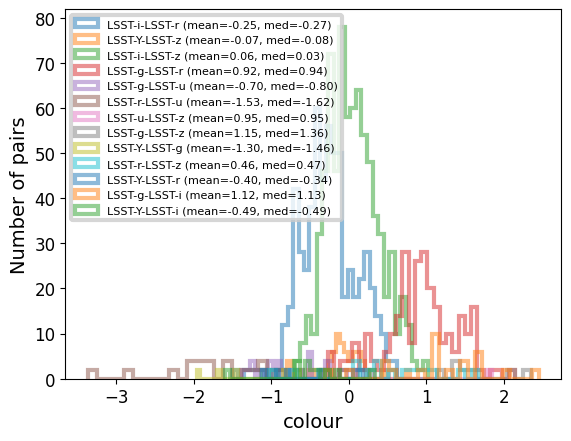

In [28]:
for c in df_colours.colour.unique():
    sel = df_colours[
        (df_colours.colour == c) & 
        (df_colours.SNR1 > 5) & 
        (df_colours.SNR2 > 5)
    ]
    if len(sel) == 0:
        continue
    
    mean_val = sel.mag_diff.mean()
    median_val = sel.mag_diff.median()
    
    # histogram
    plt.hist(sel.mag_diff, bins=30, alpha=0.5, label=f"{c} (mean={mean_val:.2f}, med={median_val:.2f})", histtype='step')
    
    # print colours
    # print(c)
    # print('mean',round(mean_val,1))
    # print('median',round(median_val,1))

plt.xlabel("colour")
plt.ylabel("Number of pairs")
plt.legend(fontsize=8)


In [29]:
df_colours_broker = df_colours[(df_colours.SNR1 > 5) & (df_colours.SNR2 > 5)]
for mod in df_colours_broker.model.unique():
    sel = df_colours_broker[df_colours_broker.model == mod]
    print(f"{mod} Min-max colours from KNe: {sel.mag_diff.min():.1f} {sel.mag_diff.max():.1f}")

Bulla Min-max colours from KNe: -2.3 1.9
Kasen Min-max colours from KNe: -3.4 2.5


NameError: name 'dic_KN_models_colors' is not defined

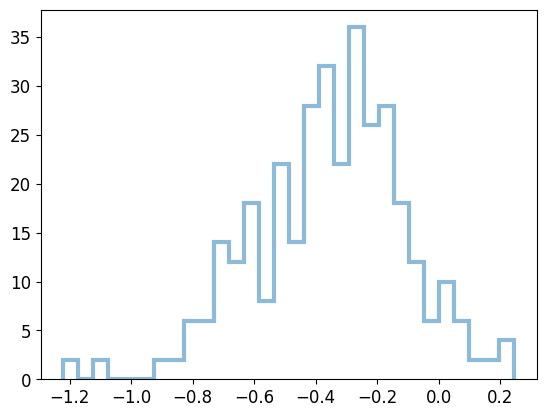

In [30]:
# Only i-r
c = 'LSST-i-LSST-r'
for mod in df_colours_broker.model.unique():
    sel = df_colours[
        (df_colours.colour == c) & 
        (df_colours.SNR1 > 5) & 
        (df_colours.SNR2 > 5) & (df_colours.model == mod)
    ]

    mean_val = sel.mag_diff.mean()
    std_val = sel.mag_diff.std()
    median_val = sel.mag_diff.median()

    # histogram
    plt.hist(sel.mag_diff, bins=30, alpha=0.5, label=f"{mod} {c} (mean={mean_val:.2f}, med={median_val:.2f})", histtype='step')
    plt.axvline(mean_val, color=dic_KN_models_colors[mod], linestyle='--', label=f"{mod} mean {mean_val:.2f}")
    print(f"{mod} {c} mean={mean_val:.2f}, std={std_val:.2f}, median={median_val:.2f}")

plt.xlabel("colour")
plt.ylabel("Number of pairs")
plt.legend(fontsize=8)


## Rate of decline

LSST-Y median 0.4 +- 0.4
LSST-i median 0.4 +- 0.3
LSST-r median 0.4 +- 0.3
LSST-z median 0.4 +- 0.4
LSST-g median 0.7 +- 0.6
LSST-u median 1.9 +- nan


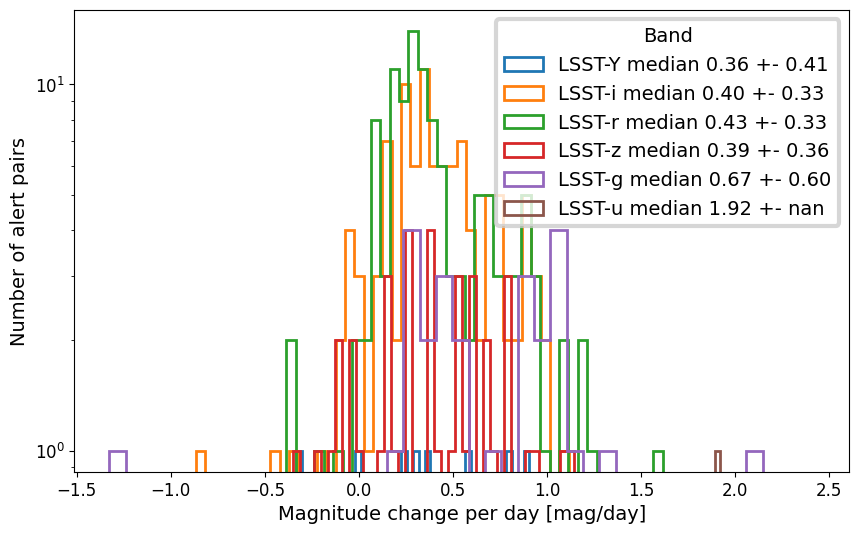

In [ ]:
# get all the SNR>5 alerts
df_snr = df_phot[df_phot["SNR"] > 5].copy()
# sort by SNID and BAND
df_snr = df_snr.sort_values(["SNID", "BAND", "MJD"])

# differences
df_snr["dm"] = df_snr.groupby(["SNID", "BAND"])["magnitude"].diff()
df_snr["dt"] = df_snr.groupby(["SNID", "BAND"])["MJD"].diff()

# only compute rate if dt > 1
df_snr["rate_mag_per_day"] = df_snr["dm"].where(df_snr["dt"] > 1) / df_snr["dt"]



plt.figure(figsize=(10,6))

for band in bands:
    sel = df_snr[df_snr["BAND"] == band]
    plt.hist(
        sel["rate_mag_per_day"].dropna(),
        bins=40,
        histtype="step",
        label=f"{band} median {sel['rate_mag_per_day'].mean():.2f} +- {sel['rate_mag_per_day'].std():.2f}",
        linewidth=2
    )
    print(f"{band} median {sel['rate_mag_per_day'].mean():.1f} +- {sel['rate_mag_per_day'].std():.1f}")

plt.xlabel("Magnitude change per day [mag/day]")
plt.ylabel("Number of alert pairs")
plt.yscale("log")
plt.legend(title="Band")
plt.show()



Bulla median 0.6 +- 0.4
Kasen median 0.3 +- 0.3


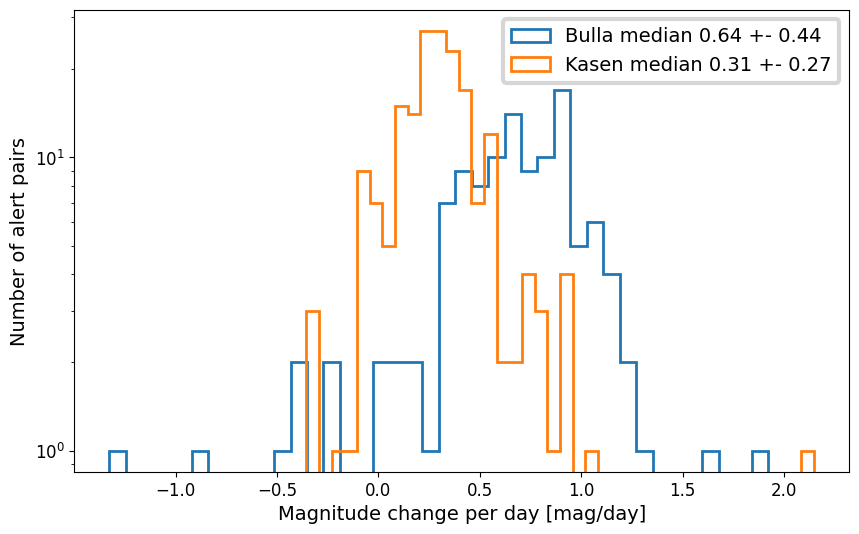

In [ ]:
# no band distinction

# get all the SNR>5 alerts
df_snr = df_phot[df_phot["SNR"] > 5].copy()
# sort by SNID and BAND
df_snr = df_snr.sort_values(["SNID", "BAND", "MJD"])

# differences
df_snr["dm"] = df_snr.groupby(["SNID", "BAND"])["magnitude"].diff()
df_snr["dt"] = df_snr.groupby(["SNID", "BAND"])["MJD"].diff()

# only compute rate if dt > 1
df_snr["rate_mag_per_day"] = df_snr["dm"].where(df_snr["dt"] > 1) / df_snr["dt"]

df_snr['model'] = df_snr['SNID'].apply(lambda x: x.split('_')[1] if '_' in x else 'Unknown')

plt.figure(figsize=(10,6))

for mod in df_snr.model.unique():
    sel = df_snr[df_snr["model"] == mod]
    plt.hist(
        sel["rate_mag_per_day"].dropna(),
        bins=40,
        histtype="step",
        label=f"{mod} median {sel['rate_mag_per_day'].mean():.2f} +- {sel['rate_mag_per_day'].std():.2f}",
        linewidth=2
    )
    print(f"{mod} median {sel['rate_mag_per_day'].mean():.1f} +- {sel['rate_mag_per_day'].std():.1f}")

plt.xlabel("Magnitude change per day [mag/day]")
plt.ylabel("Number of alert pairs")
plt.yscale("log")
plt.legend()
plt.show()



Bulla LSST-Y: median=0.38, std=0.32, N=7
Bulla LSST-i: median=0.69, std=0.37, N=41
Bulla LSST-r: median=0.75, std=0.42, N=36
Bulla LSST-z: median=0.58, std=0.31, N=22
Bulla LSST-g: median=1.04, std=0.74, N=11
Bulla LSST-u: median=1.92, std=nan, N=1
Kasen LSST-Y: median=-0.33, std=nan, N=1
Kasen LSST-i: median=0.30, std=0.22, N=68
Kasen LSST-r: median=0.29, std=0.20, N=84
Kasen LSST-z: median=0.22, std=0.36, N=18
Kasen LSST-g: median=0.44, std=0.49, N=15


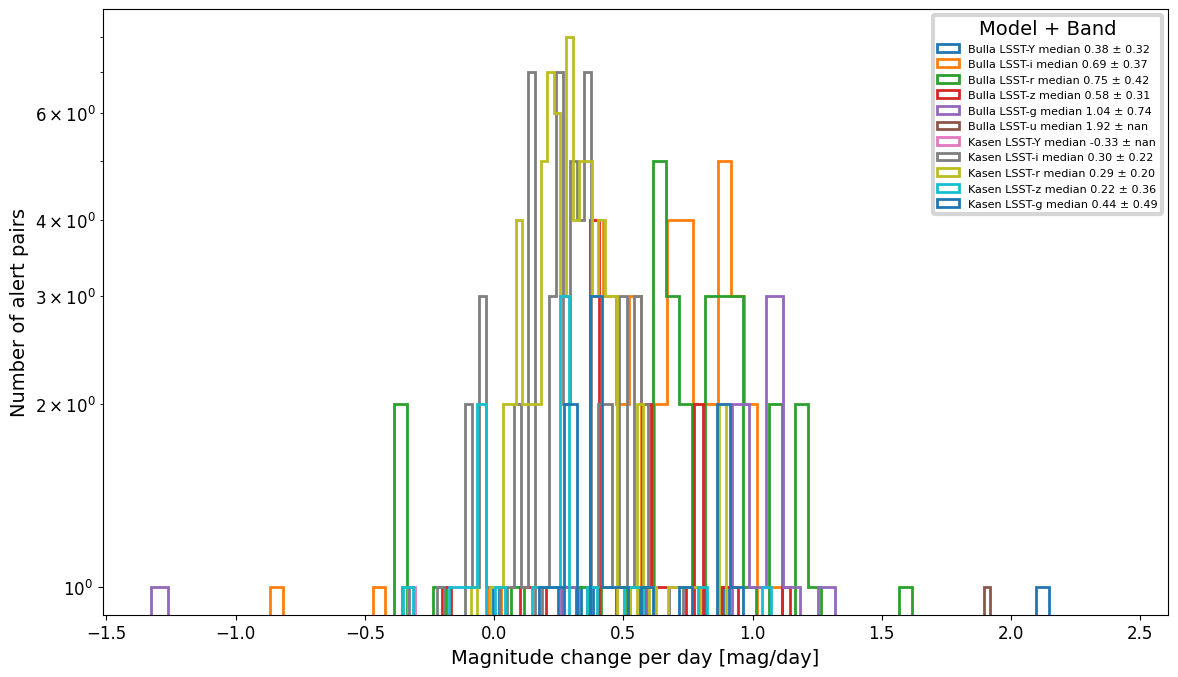

In [ ]:
import matplotlib.pyplot as plt

# get all the SNR>5 alerts
df_snr = df_phot[df_phot["SNR"] > 5].copy()
df_snr = df_snr.sort_values(["SNID", "BAND", "MJD"])

# compute differences within each SNID × BAND
df_snr["dm"] = df_snr.groupby(["SNID", "BAND"])["magnitude"].diff()
df_snr["dt"] = df_snr.groupby(["SNID", "BAND"])["MJD"].diff()

# rate, only if dt > 1
df_snr["rate_mag_per_day"] = df_snr["dm"].where(df_snr["dt"] > 1) / df_snr["dt"]

# extract model name from SNID (assumes format like "123_Bulla")
df_snr["model"] = df_snr["SNID"].apply(lambda x: x.split("_")[1] if "_" in x else "Unknown")

# plot
plt.figure(figsize=(12,7))

for mod in df_snr["model"].unique():
    for band in bands:
        sel = df_snr[(df_snr["BAND"] == band) & (df_snr["model"] == mod)]["rate_mag_per_day"].dropna()
        if len(sel) == 0:
            continue

        median_val = sel.median()
        std_val = sel.std()

        plt.hist(
            sel,
            bins=40,
            histtype="step",
            linewidth=2,
            label=f"{mod} {band} median {median_val:.2f} ± {std_val:.2f}"
        )
        print(f"{mod} {band}: median={median_val:.2f}, std={std_val:.2f}, N={len(sel)}")

plt.xlabel("Magnitude change per day [mag/day]")
plt.ylabel("Number of alert pairs")
plt.yscale("log")
plt.legend(fontsize=8, title="Model + Band")
plt.tight_layout()
plt.show()
